# Augmentation des données — notebook unique

Tout ce qui concerne l'augmentation est ici : les quatre générateurs, la couche de contraintes, le recalcul exact des features, l'ablation conjointe et l'évaluation finale sur le test scellé. Il n'y a rien à chercher dans un autre notebook.

Chaque section imprime ce qu'elle fait et pourquoi. Les prints ne sont pas décoratifs : ce sont les vérifications qu'un reviewer demandera.

---

## La question posée

Ajouter des échantillons synthétiques améliore-t-il la prédiction de `E_field` ? Et si oui, **combien** en ajouter, et **avec quelle méthode** ?

Trois sous-questions, qui ne se répondent pas séparément :

1. **Quel générateur ?** SMOTE-R, CTGAN, TVAE — les trois méthodes de référence — ou une génération qui exploite la physique du problème.
2. **Quelle taille ?** Le ratio synthétique/réel, sur une grille géométrique ×1, ×2, ×5.
3. **Combien de features ?** N, dans l'ordre de Borda du notebook 07. Un jeu élargi peut en supporter davantage, donc figer N avant de choisir le ratio n'aurait pas de sens.

Les trois sont donc balayées **conjointement** au §7, en validation croisée dans Dev, et le test n'est ouvert qu'au §9.

---

## Les quatre générateurs, en deux familles

**Famille A — génération tabulaire sous contraintes.** Le générateur produit directement un vecteur de features, puis une **couche de contraintes** le rend admissible : bornes par strate, compteurs entiers, sentinelles `-1`, identité du tilt, cohérence `LOS ⟺ Fresnel = 0`.

| Générateur | Principe |
|---|---|
| **SMOTE-R** | interpolation convexe entre un point et un de ses *k* plus proches voisins, λ appliqué aux features **et** à la cible (Torgo & Ribeiro) |
| **CTGAN** | GAN conditionnel pour données tabulaires (Xu et al., NeurIPS 2019) |
| **TVAE** | auto-encodeur variationnel tabulaire, même article |

**Famille B — génération des seules variables libres, puis recalcul.** On ne tire que la **position du récepteur**, et `radio_pipeline.py` — le portage de tes cinq scripts — **recalcule** les 17 features de géométrie, terrain et obstacles, exactement comme pour une mesure réelle.

| Générateur | Principe |
|---|---|
| **GEO-interp** | position sur le segment entre deux mesures voisines, cible interpolée avec λ ∈ [0, 1] |
| **GEO-disp** | mêmes positions, cible avec λ dilaté pour restituer la dispersion réelle (voir §5.2) |

La différence de fond entre les deux familles : en famille A les contraintes sont **imposées après coup**, en famille B elles sont **satisfaites par construction**, puisque c'est le code qui a produit les mesures réelles qui produit aussi les synthétiques. La comparaison des deux familles chiffre ce que rapporte cette exactitude.

---

## Positionnement dans la littérature

La famille A relève de la **génération tabulaire sous contraintes**, un domaine actif : Stoian et al. (ICLR 2024) intègrent une couche de contraintes au générateur et ramènent à 0 % un taux de violation supérieur à 95 % pour les modèles standards. Ici la couche est appliquée en post-traitement, ce qui est le cas d'usage « garde-fou » qu'ils décrivent aussi.

La famille B correspond à ce que la littérature appelle **dependency-aware generation** — générer les variables indépendantes, reconstruire les dépendantes par les règles connues (Umesha et al., 2025) — et, côté radio, à la **simulation-enhanced data augmentation** de Mohamed et al. (arXiv:2402.01969), qui placent des récepteurs synthétiques et en extraient les mêmes features d'ingénierie que pour les points réels. Le principe n'est donc pas inédit ; ce qui l'est ici, c'est que le « simulateur » est **ta propre chaîne d'extraction**, de sorte que features réelles et synthétiques ne peuvent pas diverger.

Sur le protocole, augmenter **avant** de découper la validation croisée est une erreur documentée : Santos et al. (IEEE Comput. Intell. Mag., 2018) prescrivent explicitement de ne sur-échantillonner que les k−1 plis d'entraînement, et Demircioğlu (Sci. Rep., 2024) chiffre le biais que l'inverse produit. Le §7.1 imprime l'audit qui atteste que ce notebook respecte la prescription.

Sur la **taille**, il n'existe pas de convention établie : `imbalanced-learn` raisonne en ratio d'équilibrage entre classes, `UBL::smoteRegress` en pourcentages par bump, et l'article CTGAN n'énonce aucune règle. La grille géométrique retenue ici se justifie par le biais de sélection (Cawley & Talbot, JMLR 2010) : la courbe RMSE contre taille est plate devant le bruit de pli, donc multiplier les points de grille ne raffine pas l'optimum, cela multiplie les occasions de tomber sur un creux de bruit. Le §8 le quantifie.

---

## Ordre d'exécution

Le **§3 est un test de non-régression** : il recalcule les features des 327 positions réelles et les compare à `radio_features.csv`. S'il ne passe pas, les chemins de rasters sont mauvais et rien de ce qui suit n'a de sens. Lance-le d'abord.


---
## §0 — Configuration

**Les cinq chemins ci-dessous sont à renseigner.** Ce sont exactement ceux de tes scripts d'origine.

In [ ]:
import warnings, json, time, os, textwrap

# ── Correctif crash SIGSEGV (libomp.dylib) ──────────────────────────────────
# PyTorch (ctgan) et sklearn/xgboost/lightgbm/catboost embarquent chacun leur
# propre copie d'OpenMP ; sur macOS, les faire cohabiter dans le même process
# fait planter le barrier/suspend d'OpenMP (SIGSEGV dans libomp.dylib).
# DOIT être fait avant tout import numpy/sklearn/xgboost/... ci-dessous.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import rasterio
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
from ctgan import CTGAN, TVAE

from radio_pipeline import compute_all_features, load_raster   # portage de tes 5 scripts

# ══════════════════════════════════════════════════════════════════════════
#  CHEMINS DES RASTERS — à renseigner
# ══════════════════════════════════════════════════════════════════════════
FABDEM_PATH  = "./data/FABDEM_Benin_DTM_UTM31N.tif"
DSM_COT_PATH = "./data/DSM_Copernicus30_Cotonou.tif"
DSM_KAN_PATH = "./data/DSM_Copernicus30_Kandi.tif"
BLD_COT_PATH = "./data/building_cotonou.tif"
BLD_KAN_PATH = "./data/building_kandi.tif"
# ══════════════════════════════════════════════════════════════════════════

BASE  = Path('.').resolve()
NB07  = BASE / 'outputs_nb07'
OUT   = BASE / 'outputs_augmentation'; OUT.mkdir(exist_ok=True)
CACHE = OUT / 'cache'; CACHE.mkdir(exist_ok=True)

SEED, TARGET = 42, 'E_field'
np.random.seed(SEED)
ML_NAMES = ['RF','XGBoost','CatBoost','LightGBM']

# ── Les axes de l ablation ─────────────────────────────────────────────────
GENERATEURS = ['SMOTE-R','CTGAN','TVAE','GEO-interp','GEO-disp']
FAMILLE     = {'SMOTE-R':'A — tabulaire sous contraintes','CTGAN':'A — tabulaire sous contraintes',
               'TVAE':'A — tabulaire sous contraintes','GEO-interp':'B — position + recalcul',
               'GEO-disp':'B — position + recalcul'}
RATIOS      = [0, 1, 2, 5]        # 0 = aucune augmentation, présent dans la grille
MAX_RATIO   = max(RATIOS)
# Grille de N : dense là où N* se trouve (tous les N* du nb07 sont <= 6),
# plus lâche au-delà où la courbe est plate. Mets list(range(1,23)) si tu veux tout.
N_GRID      = [1,2,3,4,5,6,7,8,9,10,12,14,17,19]   # 19 features au total (Wdir/Wspd/Pres retirées)

# ── Paramètres des générateurs ─────────────────────────────────────────────
K_SMOTE         = 7      # voisins candidats, famille A
K_NEIGH         = 7      # voisins candidats, famille B
MAX_PAIR_DIST_M = 400    # tolérance sur l écart entre les deux parents, famille B
CTGAN_EPOCHS    = 300
TVAE_EPOCHS     = 300
ALPHA_GRID      = np.arange(0.0, 0.65, 0.05)   # dilatation de lambda, GEO-disp
N_FOLDS         = 5
N_REPEATS_CV    = 2      # comme ABL_REPEATS en nb07 : 5 plis x 2 répétitions = 10 estimations,
                          # pour que la courbe "aucun" soit calculée avec EXACTEMENT le même
                          # protocole que l'ablation Pure ML de nb07 (mêmes plis, même seed,
                          # mêmes hyperparamètres) et retombe donc naturellement sur le même N*.

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,'font.size':11})

def bandeau(titre, lignes):
    '''Encadré explicatif, pour que la sortie se lise sans le code.'''
    print('\n' + '═'*78); print('  ' + titre); print('═'*78)
    for l in lignes:
        for w in textwrap.wrap(l, 76, initial_indent='  ', subsequent_indent='    ') or ['']:
            print(w)
    print()

# ── Modèles et hyperparamètres, repris du notebook 07 ──────────────────────
with open(NB07/'best_params_dev.json') as f: BEST = json.load(f)
imp = pd.read_csv(NB07/'feature_importance_multi_dev.csv', index_col=0)
TIE = ['First_building_m','Fresnel_trees']
BORDA_ORDER = []
for r in sorted(imp['Borda_rank'].unique()):
    g = imp[imp['Borda_rank']==r].index.tolist()
    if len(g)>1: g = [f for f in TIE if f in g] + [f for f in g if f not in TIE]
    BORDA_ORDER.extend(g)
NSTAR = {k:int(v) for k,v in pd.read_csv(NB07/'nstar_selection_dev.csv')[['Model','N*']].values}

def build_ml(name):
    p = BEST[name].copy()
    if name=='RF':       return RandomForestRegressor(random_state=SEED, n_jobs=-1, **p)
    if name=='XGBoost':  return XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0, **p)
    if name=='CatBoost': return CatBoostRegressor(random_seed=SEED, verbose=0, thread_count=-1, **p)
    if name=='LightGBM': return lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1, **p)

def evaluate(y,p):
    return {'RMSE':float(np.sqrt(mean_squared_error(y,p))),'MAE':float(mean_absolute_error(y,p)),
            'R2':float(r2_score(y,p)),'Bias':float(np.mean(p-y))}

NCONF = 1 + len(GENERATEURS)*(len(RATIOS)-1)
bandeau('CE QUE CE NOTEBOOK VA BALAYER', [
  f'{len(GENERATEURS)} générateurs : ' + ', '.join(GENERATEURS),
  f'{len(RATIOS)} ratios : ' + ', '.join('aucun' if r==0 else f'×{r}' for r in RATIOS)
  + '  (grille géométrique, voir l introduction)',
  f'{len(N_GRID)} valeurs de N dans l ordre de Borda : {N_GRID}',
  f'{len(ML_NAMES)} modèles : ' + ', '.join(ML_NAMES) + ' — hyperparamètres figés au notebook 07,'
  ' donc aucune optimisation ne se refait ici et rien ne peut fuir par ce canal.',
  '',
  f'Soit {NCONF} configurations d augmentation × {len(N_GRID)} valeurs de N × {len(ML_NAMES)}'
  f' modèles × {N_FOLDS}×{N_REPEATS_CV} plis = {NCONF*len(N_GRID)*len(ML_NAMES)*N_FOLDS*N_REPEATS_CV} ajustements.',
  'La génération, elle, n a lieu qu une fois par pli et par générateur, au ratio maximal :'
  ' les ratios inférieurs en sont des sous-échantillons, ce qui rend les comparaisons appariées.'])

print('N* retenus au notebook 07, sans augmentation :', NSTAR)
print('Ordre de Borda (10 premières) :', ', '.join(BORDA_ORDER[:10]))
print()
missing = [p for p in [FABDEM_PATH,DSM_COT_PATH,DSM_KAN_PATH,BLD_COT_PATH,BLD_KAN_PATH]
           if not os.path.exists(p)]
if missing:
    print('RASTERS INTROUVABLES — renseigne les chemins ci-dessus :')
    for p in missing: print('   ', p)
else:
    print('Les cinq rasters sont accessibles.')

---
## §1 — Ouverture des rasters

Trois sources de terrain, ouvertes une seule fois et gardées en mémoire : le **FABDEM** (modèle de terrain, sol nu) sert au profil altimétrique et à la hauteur du sol ; les **DSM Copernicus GLO-30** donnent la hauteur du sursol ; les **rasters de bâtiments** distinguent bâti et végétation. La différence DSM − FABDEM est la hauteur de l'obstacle, et le raster de bâtiments dit sa nature.

In [2]:
dem_ds      = rasterio.open(FABDEM_PATH)   # dataset ouvert, pour dem.sample() le long du profil
fab, tr_fab = load_raster(FABDEM_PATH)     # tableau en mémoire, pour get_value() ponctuel
RASTERS = {'dem': dem_ds, 'fabdem': fab, 'tr_fab': tr_fab}
for city, dsm_p, bld_p in [('cotonou', DSM_COT_PATH, BLD_COT_PATH),
                           ('kandi',   DSM_KAN_PATH, BLD_KAN_PATH)]:
    dsm, tr_dsm = load_raster(dsm_p)
    bld, tr_bld = load_raster(bld_p)
    RASTERS[city] = {'dsm':dsm,'tr_dsm':tr_dsm,'bld':bld,'tr_bld':tr_bld}
    print(f'{city:9s} DSM {str(dsm.shape):14s} bâtiments {bld.shape}')
print(f'FABDEM    {str(fab.shape):14s} CRS {dem_ds.crs}')
print()
print('Constantes de la chaîne, identiques à tes scripts : pas de 30 m le long du profil,')
print('500 échantillons pour la zone de Fresnel, rayon local 50 m, extension 50 m au-delà du Rx,')
print('grille polaire 36 × 10 autour du Rx, seuils 1 m pour le bâti et 2 m pour la végétation.')

cotonou   DSM (378, 549)     bâtiments (376, 554)
kandi     DSM (179, 235)     bâtiments (178, 230)
FABDEM    (25322, 18066) CRS EPSG:32631

Constantes de la chaîne, identiques à tes scripts : pas de 30 m le long du profil,
500 échantillons pour la zone de Fresnel, rayon local 50 m, extension 50 m au-delà du Rx,
grille polaire 36 × 10 autour du Rx, seuils 1 m pour le bâti et 2 m pour la végétation.


---
## §2 — Données réelles et split Dev/Test

Le split est identique aux notebooks précédents : stratifié par `Environment`, `random_state=42`. **Le test est scellé ici et n'est rouvert qu'au §9.** Tout ce qui se décide entre les deux — générateur, ratio, N — se décide dans Dev.

Les 22 features se répartissent en trois groupes selon leur sort pendant l'augmentation, et cette répartition est le cœur de la méthode.

In [3]:
df  = pd.read_csv(BASE/'radio_features_clean_ref.csv')
raw = pd.read_csv(BASE/'radio_features.csv')
GEO_COLS = ['Rx_lat','Rx_lon','Tx_lat','Tx_lon','Tx_alt','Tx_id','City']
df  = df.join(raw.set_index('Ref')[GEO_COLS], on='Ref')
df['stratum'] = df.City + '/' + df.Tx_id

FEAT_GROUPS = {'System':['Tx_power','Tx_height','Freq'],'Distance':['Distance'],
 'Terrain':['Slope_Tx_Rx_50m','Roughness_Tx_Rx_50m','Rx_height'],
 'Geometry':['Azimut_Tx_Rx','Tilt_Tx_Rx'],
 'Obstacles':['LOS','First_building_m','First_tree_m','Fresnel_buildings','Fresnel_trees',
              'Buildings_near_Rx','Trees_near_Rx'],
 'Meteo':['Temp','Rhum'],'Context':['Environment']}
ALL_FEATURES = [f for v in FEAT_GROUPS.values() for f in v]
METEO   = FEAT_GROUPS['Meteo']
CALCUL  = (FEAT_GROUPS['Distance'] + FEAT_GROUPS['Terrain'] +
           FEAT_GROUPS['Geometry'] + FEAT_GROUPS['Obstacles'])   # recalculables (famille B)
FIXES   = FEAT_GROUPS['System'] + FEAT_GROUPS['Context']          # constantes dans une strate

# Blocs utilisés par la famille A (génération tabulaire)
CAT_BLOCK  = ['Freq','Tx_power','Environment','Tx_height','Tx_antenna_height','Rx_antenna_height']
FREE_CONT  = ['Distance','Azimut_Tx_Rx','Rx_height','Slope_Tx_Rx_50m','Roughness_Tx_Rx_50m']
FREE_COUNT = ['Fresnel_buildings','Fresnel_trees','Buildings_near_Rx','Trees_near_Rx']
FREE_FRAC  = ['frac_building','frac_tree']
GEN_COLS   = FREE_CONT + FREE_COUNT + FREE_FRAC + [TARGET]
df['frac_building'] = np.where(df.First_building_m>0, df.First_building_m/df.Distance, 0.0)
df['frac_tree']     = np.where(df.First_tree_m>0,     df.First_tree_m/df.Distance,     0.0)

dev_df, test_df = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df['Environment'])
dev_df, test_df = dev_df.reset_index(drop=True), test_df.reset_index(drop=True)

bandeau('LE SPLIT', [
  f'Dev {len(dev_df)} points ({100*len(dev_df)/len(df):.1f} %) — tout se décide ici.',
  f'Test {len(test_df)} points ({100*len(test_df)/len(df):.1f} %) — scellé jusqu au §9.',
  f'Urbain : {100*df.Environment.mean():.2f} % global, {100*dev_df.Environment.mean():.2f} % dans Dev,'
  f' {100*test_df.Environment.mean():.2f} % dans le test — la stratification tient.'])
print('Effectifs par strate (ville / émetteur) dans Dev :')
print(dev_df.groupby('stratum').size().rename('n').to_string())

bandeau(f'LE SORT DES {len(ALL_FEATURES)} FEATURES PENDANT L AUGMENTATION', [
  f'RECALCULABLES ({len(CALCUL)}) — famille B les obtient de la chaîne d extraction, famille A les génère :',
  '    ' + ', '.join(CALCUL),
  '',
  f'CONSTANTES DANS UNE STRATE ({len(FIXES)}) — héritées du point parent dans les deux familles :',
  '    ' + ', '.join(FIXES),
  '',
  f'MÉTÉO ({len(METEO)}) — ne se calcule pas et ne se génère pas : le bloc entier est hérité du',
  '    parent, jamais recomposé valeur par valeur. Sa distribution jointe est donc préservée',
  '    exactement, et la corrélation Rhum/Temp aussi (r = '
  f'{dev_df.Rhum.corr(dev_df.Temp):.2f}).',
  '',
  'CIBLE — E_field ne se calcule pas davantage. C est la seule quantité vraiment interpolée,',
  '    dans les deux familles, et donc la seule hypothèse de toute la méthode.'])


══════════════════════════════════════════════════════════════════════════════
  LE SPLIT
══════════════════════════════════════════════════════════════════════════════
  Dev 261 points (79.8 %) — tout se décide ici.
  Test 66 points (20.2 %) — scellé jusqu au §9.
  Urbain : 64.53 % global, 64.37 % dans Dev, 65.15 % dans le test — la
    stratification tient.

Effectifs par strate (ville / émetteur) dans Dev :
stratum
cotonou/ABCA     15
cotonou/COTO    153
kandi/KAND       93

══════════════════════════════════════════════════════════════════════════════
  LE SORT DES 19 FEATURES PENDANT L AUGMENTATION
══════════════════════════════════════════════════════════════════════════════
  RECALCULABLES (13) — famille B les obtient de la chaîne d extraction,
    famille A les génère :
      Distance, Slope_Tx_Rx_50m, Roughness_Tx_Rx_50m, Rx_height,
    Azimut_Tx_Rx, Tilt_Tx_Rx, LOS, First_building_m, First_tree_m,
    Fresnel_buildings, Fresnel_trees, Buildings_near_Rx, Trees_near_Rx

  CONS

---
## §3 — Test de non-régression du portage

On recalcule les features des **327 positions réelles** et on les compare à `radio_features.csv`. `Distance` et `Azimut_Tx_Rx` ne dépendent pas des rasters : ils doivent coïncider au chiffre près. Les autres valident que les rasters sont les bons et correctement géoréférencés.

Si cette cellule ne passe pas, tout ce qui suit est sans valeur.

In [4]:
bandeau('CE QUE FAIT CETTE CELLULE', [
  'Elle rejoue compute_all_features sur les 327 positions RÉELLES et compare le résultat aux',
  'valeurs du fichier d origine. C est le seul moyen de savoir que le portage des cinq scripts',
  'est fidèle et que les rasters branchés sont les bons. Elle mesure aussi le coût par point,',
  'qui détermine le temps de génération du §7.'])

t0 = time.time(); rows = []
for _, r in df.iterrows():
    tx = dict(Tx_lat=r.Tx_lat, Tx_lon=r.Tx_lon, Tx_alt=r.Tx_alt,
              Tx_antenna_height=r.Tx_antenna_height, Tx_power=r.Tx_power,
              Freq=r.Freq, City=r.City, Tx_id=r.Tx_id)
    rows.append(compute_all_features(r.Rx_lat, r.Rx_lon, tx, RASTERS))
rec = pd.DataFrame(rows); dt = time.time()-t0
COUT_PAR_POINT = dt/len(rec)
print(f'{len(rec)} positions recalculées en {dt:.0f} s ({COUT_PAR_POINT:.3f} s/point)\n')

check = ['Distance','Azimut_Tx_Rx','Tilt_Tx_Rx','Rx_height','Slope_Tx_Rx_50m',
         'Roughness_Tx_Rx_50m','LOS','First_building_m','First_tree_m',
         'Fresnel_buildings','Fresnel_trees','Buildings_near_Rx','Trees_near_Rx']
print(f'{"feature":24s} {"écart médian":>14s} {"écart max":>13s}   verdict')
print('-'*72)
ok_geom = True
for c in check:
    a, b = rec[c].values.astype(float), df[c].values.astype(float)
    e = np.abs(a-b)
    tol = 1e-6 if c in ('Distance','Azimut_Tx_Rx','Tilt_Tx_Rx','Rx_height') else 0
    verdict = ('exact' if e.max() <= max(tol,1e-9)
               else ('proche' if np.median(e) < 0.05*max(np.std(b),1e-9) else 'DIVERGE'))
    if c in ('Distance','Azimut_Tx_Rx') and e.max() > 1e-6: ok_geom = False
    print(f'{c:24s} {np.median(e):14.3e} {e.max():13.3e}   {verdict}')
print()
print('Géométrie (Distance, Azimut) :', 'CONFORME' if ok_geom else 'ÉCHEC — vérifie les colonnes Tx')
rec.to_csv(CACHE/'recompute_reel.csv', index=False)
n_gen_prevu = N_FOLDS*int(len(dev_df)*(1-1/N_FOLDS))*MAX_RATIO
print()
print(f'Coût prévisionnel de la génération famille B au §7 : ~{n_gen_prevu} points, '
      f'soit ~{n_gen_prevu*COUT_PAR_POINT/60:.0f} min. Mise en cache : une seule fois.')


══════════════════════════════════════════════════════════════════════════════
  CE QUE FAIT CETTE CELLULE
══════════════════════════════════════════════════════════════════════════════
  Elle rejoue compute_all_features sur les 327 positions RÉELLES et compare
    le résultat aux
  valeurs du fichier d origine. C est le seul moyen de savoir que le portage
    des cinq scripts
  est fidèle et que les rasters branchés sont les bons. Elle mesure aussi le
    coût par point,
  qui détermine le temps de génération du §7.



327 positions recalculées en 5 s (0.015 s/point)

feature                    écart médian     écart max   verdict
------------------------------------------------------------------------
Distance                      0.000e+00     1.364e-12   exact
Azimut_Tx_Rx                  0.000e+00     5.684e-14   exact
Tilt_Tx_Rx                    0.000e+00     1.776e-15   exact
Rx_height                     0.000e+00     5.684e-14   exact
Slope_Tx_Rx_50m               4.510e-17     9.888e-17   exact
Roughness_Tx_Rx_50m           0.000e+00     1.776e-15   exact
LOS                           0.000e+00     0.000e+00   exact
First_building_m              0.000e+00     9.095e-13   exact
First_tree_m                  0.000e+00     4.547e-13   exact
Fresnel_buildings             0.000e+00     0.000e+00   exact
Fresnel_trees                 0.000e+00     0.000e+00   exact
Buildings_near_Rx             0.000e+00     0.000e+00   exact
Trees_near_Rx                 0.000e+00     0.000e+00   exact

Géomét

---
## §4 — Famille A : génération tabulaire sous contraintes

Les trois générateurs de référence produisent un vecteur de features. Aucun d'eux ne peut savoir que `Distance`, `Tilt_Tx_Rx`, `LOS` et les compteurs de Fresnel sont liés entre eux — un GAN apprend une loi jointe, pas une identité trigonométrique. D'où la **couche de contraintes**, appliquée après génération.

### Les huit invariants imposés

| Contrainte | Justification |
|---|---|
| bornes par strate sur les continues | on ne génère pas hors du domaine observé pour cet émetteur |
| compteurs entiers et bornés | `Fresnel_*`, `*_near_Rx` comptent des obstacles |
| `LOS = 1 ⟺ Fresnel_b + Fresnel_t = 0` | définition de la visibilité directe |
| `First_building_m = −1 ⟺ Fresnel_buildings = 0` | la sentinelle code « pas d'obstacle » |
| `First_tree_m = −1 ⟺ Fresnel_trees = 0` | idem |
| `First_*_m ≤ Distance` | l'obstacle est sur le trajet, généré comme fraction de la distance |
| `Tilt = arctan((Tx_height − Rx_height)/Distance)` | identité géométrique exacte |
| bloc `System`/`Context` constant dans la strate | même émetteur, même fréquence, même environnement |

La météo n'est pas générée : le **bloc entier** est hérité du parent pour SMOTE-R, ou tiré parmi les tuples observés de la strate pour CTGAN et TVAE. Une météo recomposée valeur par valeur produirait des combinaisons impossibles.

In [5]:
def learn_bounds(train):
    '''Domaine admissible, appris sur la SEULE portion d entrainement qu on lui passe.'''
    B = {}
    for s, g in train.groupby('stratum'):
        b = {'cat':{c:g[c].iloc[0] for c in CAT_BLOCK},
             'meteo_pool': g[METEO].drop_duplicates().values,
             'cont': {c:(g[c].min(), g[c].max()) for c in FREE_CONT},
             'count':{c:(int(g[c].min()), int(g[c].max())) for c in FREE_COUNT},
             'y':(g[TARGET].min(), g[TARGET].max())}
        for k in ['frac_building','frac_tree']:
            pos = g[g[k]>0][k]; b[k] = (pos.min(), pos.max()) if len(pos) else (0.87, 0.98)
        B[s] = b
    return B

def repair(syn, s, B):
    '''La couche de contraintes. Rend admissible un vecteur généré librement.'''
    b = B[s]; o = syn.copy()
    for c in FREE_CONT:  o[c] = o[c].clip(*b['cont'][c])
    for c in FREE_COUNT: o[c] = np.rint(o[c]).clip(*b['count'][c]).astype(int)
    o[TARGET] = o[TARGET].clip(*b['y'])
    for c, v in b['cat'].items(): o[c] = v
    o['LOS'] = ((o.Fresnel_buildings + o.Fresnel_trees) == 0).astype(int)
    for kind, cnt, fr, col in [('building','Fresnel_buildings','frac_building','First_building_m'),
                               ('tree','Fresnel_trees','frac_tree','First_tree_m')]:
        f = o[fr].clip(*b[f'frac_{kind}'])
        o[col] = np.where(o[cnt] == 0, -1.0, f*o['Distance'])
    o['Tilt_Tx_Rx'] = np.degrees(np.arctan((o.Tx_height - o.Rx_height)/o.Distance))
    return o

def validate(d, B, label=''):
    '''Vérifie les huit invariants. Sert de preuve, pas de garde-fou.'''
    v = {}
    v['LOS <-> Fresnel']      = int((((d.Fresnel_buildings+d.Fresnel_trees)==0) != (d.LOS==1)).sum())
    v['sentinelle bâtiments'] = int(((d.First_building_m==-1) != (d.Fresnel_buildings==0)).sum())
    v['sentinelle arbres']    = int(((d.First_tree_m==-1)     != (d.Fresnel_trees==0)).sum())
    v['First_b <= Distance']  = int((d.loc[d.First_building_m>0,'First_building_m'] >
                                     d.loc[d.First_building_m>0,'Distance']).sum())
    v['First_t <= Distance']  = int((d.loc[d.First_tree_m>0,'First_tree_m'] >
                                     d.loc[d.First_tree_m>0,'Distance']).sum())
    tilt = np.degrees(np.arctan((d.Tx_height-d.Rx_height)/d.Distance))
    v['identité Tilt']        = int(((d.Tilt_Tx_Rx-tilt).abs() > 1e-6).sum())
    v['compteurs entiers']    = int(sum((d[c] != np.rint(d[c])).sum() for c in FREE_COUNT))
    if B is not None:
        v['hors plage strate'] = int(sum(
            ((g[c] < B[s]['cont'][c][0]-1e-9) | (g[c] > B[s]['cont'][c][1]+1e-9)).sum()
            for s, g in d.groupby('stratum') if s in B for c in FREE_CONT))
    tot = sum(v.values())
    if label:
        print(f'  {label:34s} {"CONFORME" if tot==0 else str(tot)+" VIOLATIONS"}'
              + ('' if tot==0 else '  ' + str({k:x for k,x in v.items() if x})))
    return v

def gen_smote(g, n, rng):
    '''SMOTE-R : interpolation convexe vers un des k plus proches voisins, dans l espace
       standardisé. lambda ~ U(0,1) appliqué aux features ET à la cible.'''
    Z = StandardScaler().fit_transform(g[GEN_COLS[:-1]].values)
    k = min(K_SMOTE, len(g)-1)
    _, idx = NearestNeighbors(n_neighbors=k+1).fit(Z).kneighbors(Z)
    i = rng.integers(0, len(g), size=n); j = idx[i, rng.integers(1, k+1, size=n)]
    lam = rng.uniform(0, 1, size=(n,1))
    A, Bv = g[GEN_COLS].values[i], g[GEN_COLS].values[j]
    return pd.DataFrame(A + lam*(Bv-A), columns=GEN_COLS), g.iloc[i]

def gen_neural(g, n, kind):
    '''CTGAN ou TVAE ajusté sur le bloc libre + cible, compteurs déclarés discrets.'''
    m = (CTGAN(epochs=CTGAN_EPOCHS, pac=10, verbose=False) if kind=='CTGAN'
         else TVAE(epochs=TVAE_EPOCHS))
    m.fit(g[GEN_COLS], discrete_columns=FREE_COUNT)
    return m.sample(n), None

def augment_tabulaire(train, n_per, methode, rng, B, verbeux=False):
    '''Famille A : génère, applique la couche de contraintes, hérite la météo.'''
    pieces = []
    for s, g in train.groupby('stratum'):
        n = n_per.get(s, 0)
        if n <= 0 or len(g) < K_SMOTE+2: continue
        t0 = time.time()
        syn, parents = (gen_smote(g, n, rng) if methode=='SMOTE-R' else gen_neural(g, n, methode))
        syn['stratum'] = s
        syn = repair(syn, s, B)
        syn[METEO] = (parents[METEO].values if parents is not None
                      else B[s]['meteo_pool'][rng.integers(0, len(B[s]['meteo_pool']), size=len(syn))])
        pieces.append(syn)
        if verbeux:
            print(f'    {methode:8s} strate {s:14s} {n:5d} points en {time.time()-t0:5.1f} s')
    if not pieces:
        return train.iloc[0:0][ALL_FEATURES+[TARGET,'stratum']]
    return pd.concat(pieces, ignore_index=True)[ALL_FEATURES+[TARGET,'stratum']]

bandeau('FAMILLE A — DÉMONSTRATION SUR DEV ENTIER', [
  'Chaque générateur produit ici autant de points synthétiques que Dev compte de points réels',
  '(ratio ×1), puis la couche de contraintes est appliquée et les invariants sont vérifiés.',
  'CTGAN et TVAE sont entraînés strate par strate, 300 époques : compte quelques minutes.'])

B_dev  = learn_bounds(dev_df)
n_dev  = dev_df.groupby('stratum').size().to_dict()
DEMO_A = {}
for meth in ['SMOTE-R','CTGAN','TVAE']:
    t0 = time.time()
    DEMO_A[meth] = augment_tabulaire(dev_df, n_dev, meth, np.random.default_rng(SEED), B_dev,
                                     verbeux=True)
    print(f'  {meth:8s} total {len(DEMO_A[meth]):5d} points en {time.time()-t0:5.1f} s')

print()
print('Invariants APRÈS la couche de contraintes :')
for meth in ['SMOTE-R','CTGAN','TVAE']: validate(DEMO_A[meth], B_dev, meth)
print()
print('Invariants AVANT la couche de contraintes, sur un tirage CTGAN brut — c est ce que')
print('produirait un générateur tabulaire laissé libre :')
brut = gen_neural(dev_df[dev_df.stratum==dev_df.stratum.mode()[0]], 200, 'CTGAN')[0]
brut['stratum'] = dev_df.stratum.mode()[0]
for c, v in B_dev[dev_df.stratum.mode()[0]]['cat'].items(): brut[c] = v
brut['LOS'] = 1; brut['First_building_m'] = brut.frac_building*brut.Distance
brut['First_tree_m'] = brut.frac_tree*brut.Distance
brut['Tilt_Tx_Rx'] = 0.0
validate(brut, None, 'CTGAN brut, sans contraintes')


══════════════════════════════════════════════════════════════════════════════
  FAMILLE A — DÉMONSTRATION SUR DEV ENTIER
══════════════════════════════════════════════════════════════════════════════
  Chaque générateur produit ici autant de points synthétiques que Dev compte
    de points réels
  (ratio ×1), puis la couche de contraintes est appliquée et les invariants
    sont vérifiés.
  CTGAN et TVAE sont entraînés strate par strate, 300 époques : compte
    quelques minutes.

    SMOTE-R  strate cotonou/ABCA      15 points en   0.0 s
    SMOTE-R  strate cotonou/COTO     153 points en   0.0 s
    SMOTE-R  strate kandi/KAND        93 points en   0.0 s
  SMOTE-R  total   261 points en   0.0 s


    CTGAN    strate cotonou/ABCA      15 points en  27.6 s


    CTGAN    strate cotonou/COTO     153 points en  26.4 s


    CTGAN    strate kandi/KAND        93 points en  25.5 s
  CTGAN    total   261 points en  79.5 s


    TVAE     strate cotonou/ABCA      15 points en  12.6 s


    TVAE     strate cotonou/COTO     153 points en  12.8 s


    TVAE     strate kandi/KAND        93 points en  12.1 s
  TVAE     total   261 points en  37.5 s

Invariants APRÈS la couche de contraintes :
  SMOTE-R                            CONFORME
  CTGAN                              CONFORME
  TVAE                               CONFORME

Invariants AVANT la couche de contraintes, sur un tirage CTGAN brut — c est ce que
produirait un générateur tabulaire laissé libre :


  CTGAN brut, sans contraintes       614 VIOLATIONS  {'LOS <-> Fresnel': 105, 'sentinelle bâtiments': 158, 'sentinelle arbres': 118, 'First_b <= Distance': 9, 'First_t <= Distance': 24, 'identité Tilt': 200}


{'LOS <-> Fresnel': 105,
 'sentinelle bâtiments': 158,
 'sentinelle arbres': 118,
 'First_b <= Distance': 9,
 'First_t <= Distance': 24,
 'identité Tilt': 200,
 'compteurs entiers': 0}

---
## §5 — Famille B : génération des variables libres, puis recalcul

Ici on ne génère plus de features. On tire **la position du récepteur** — deux nombres — sur le segment reliant deux mesures réelles voisines de la même strate, et `radio_pipeline` calcule le reste depuis les rasters. C'est ce que la littérature appelle *dependency-aware generation* : générer les variables indépendantes, reconstruire les dépendantes par les règles connues.

Conséquence : **il n'y a plus de couche de contraintes**. Les huit invariants du §4 sont vrais parce que c'est le code d'origine qui produit les valeurs, pas parce qu'on les a forcés. Le §5.1 le vérifie sans rien réparer.

In [6]:
def eligible_pairs(train, max_d=MAX_PAIR_DIST_M, k=K_NEIGH):
    '''Paires (i, j) de la même strate, distantes de moins de max_d mètres.'''
    pairs = {}
    for s, g in train.groupby('stratum'):
        if len(g) < 3: continue
        xy = np.c_[g.Rx_lat.values, g.Rx_lon.values] * 111000.0
        kk = min(k, len(g)-1)
        dist, idx = NearestNeighbors(n_neighbors=kk+1).fit(xy).kneighbors(xy)
        P = [(g.index[i], g.index[idx[i,m]], dist[i,m])
             for i in range(len(g)) for m in range(1, kk+1) if dist[i,m] <= max_d]
        if P: pairs[s] = P
    return pairs

def generate_positions(train, n_per, rng, max_d=MAX_PAIR_DIST_M):
    '''Positions synthétiques, avec les deux cibles parentes et le lambda du tirage.
       On garde y_a, y_b et lam pour pouvoir recalculer la cible en forme close ensuite,
       sans retoucher aux rasters.'''
    P = eligible_pairs(train, max_d); out = []
    for s, n in n_per.items():
        if n <= 0 or s not in P: continue
        cand = P[s]
        for t in rng.integers(0, len(cand), size=n):
            i, j, d_ij = cand[t]
            lam = rng.uniform(0, 1)
            a, b = train.loc[i], train.loc[j]
            out.append({'rx_lat': a.Rx_lat + lam*(b.Rx_lat-a.Rx_lat),
                        'rx_lon': a.Rx_lon + lam*(b.Rx_lon-a.Rx_lon),
                        'y_a': a[TARGET], 'y_b': b[TARGET], 'lam': lam,
                        'parent': i, 'stratum': s, 'pair_dist': d_ij})
    return pd.DataFrame(out)

bandeau('LES PAIRES ÉLIGIBLES', [
  f'Une paire est retenue si les deux mesures appartiennent à la même strate et sont distantes',
  f'de moins de {MAX_PAIR_DIST_M} m. C est ce seuil qui borne le bruit d étiquette : plus les',
  'parents sont proches, plus l interpolation de E_field entre eux est défendable.',
  'La colonne |ΔE| ci-dessous est l ordre de grandeur de ce bruit — à comparer au RMSE des',
  'modèles, autour de 5 dB.'])
for s, P in eligible_pairs(dev_df).items():
    dd  = np.array([p[2] for p in P])
    sub = dev_df.loc[[p[0] for p in P], TARGET].values
    oth = dev_df.loc[[p[1] for p in P], TARGET].values
    print(f'  {s:16s} {len(P):5d} paires | distance médiane {np.median(dd):5.0f} m'
          f' | |ΔE| médian entre parents {np.median(np.abs(sub-oth)):5.2f} dB')


══════════════════════════════════════════════════════════════════════════════
  LES PAIRES ÉLIGIBLES
══════════════════════════════════════════════════════════════════════════════
  Une paire est retenue si les deux mesures appartiennent à la même strate
    et sont distantes
  de moins de 400 m. C est ce seuil qui borne le bruit d étiquette : plus
    les
  parents sont proches, plus l interpolation de E_field entre eux est
    défendable.
  La colonne |ΔE| ci-dessous est l ordre de grandeur de ce bruit — à
    comparer au RMSE des
  modèles, autour de 5 dB.

  cotonou/ABCA        16 paires | distance médiane   329 m | |ΔE| médian entre parents  3.25 dB
  cotonou/COTO       476 paires | distance médiane   309 m | |ΔE| médian entre parents  5.95 dB
  kandi/KAND         292 paires | distance médiane   285 m | |ΔE| médian entre parents  2.60 dB


### §5.1 — La cible : deux lois d'interpolation en concurrence

C'est le seul endroit où une hypothèse entre. L'interpolation convexe stricte pousse les points vers l'intérieur du nuage et **contracte la dispersion** de la cible — la faiblesse connue de SMOTE en régression. Deux lois sont donc mises en concurrence, sur exactement les mêmes positions :

- **GEO-interp** — λ_y = λ, la cible suit la position ;
- **GEO-disp** — λ_y = λ(1 + 2α) − α, une dilatation affine autour du milieu du segment, avec α calibré par strate **sur le seul pli d'entraînement** pour que l'écart-type synthétique retrouve l'écart-type réel, le résultat étant reclippé dans l'intervalle réel de la strate.

Ce n'est pas moi qui tranche entre les deux : elles entrent toutes les deux dans la grille du §7.

In [7]:
def target_bounds(train):
    return {s: (g[TARGET].min(), g[TARGET].max()) for s, g in train.groupby('stratum')}

def target_from_lambda(pos, alpha_by_stratum, bounds):
    y = np.empty(len(pos))
    for s, g in pos.groupby('stratum'):
        a = float(alpha_by_stratum.get(s, 0.0))
        ly = g.lam.values*(1+2*a) - a
        lo, hi = bounds[s]
        y[g.index.values] = np.clip(g.y_a.values + ly*(g.y_b.values - g.y_a.values), lo, hi)
    return y

def calibrate_alpha(pos, train):
    '''alpha par strate, choisi pour que l ecart-type synthetique colle au reel.
       Ne regarde que la portion d entrainement qu on lui passe.'''
    bounds = target_bounds(train); A = {}
    for s, g in pos.groupby('stratum'):
        ref = train[train.stratum==s][TARGET].std()
        if not np.isfinite(ref) or ref <= 0: A[s] = 0.0; continue
        lo, hi = bounds[s]; best, ba = None, 0.0
        for a in ALPHA_GRID:
            ly = g.lam.values*(1+2*a) - a
            y  = np.clip(g.y_a.values + ly*(g.y_b.values - g.y_a.values), lo, hi)
            e  = abs(y.std()/ref - 1)
            if best is None or e < best: best, ba = e, float(a)
        A[s] = ba
    return A

def build_synthetic(train, n_per, rng, tag=''):
    '''Famille B : positions, recalcul complet des features, puis les deux cibles.
       Le recalcul est mis en cache : c est l etape couteuse.'''
    cache_f = CACHE / f'syn_{tag}.csv'
    if cache_f.exists():
        syn = pd.read_csv(cache_f)
    else:
        pos = generate_positions(train, n_per, rng)
        if len(pos) == 0: return pd.DataFrame(columns=ALL_FEATURES+[TARGET]), {}
        rows = []
        for _, p in pos.iterrows():
            par = train.loc[p['parent']]
            tx = dict(Tx_lat=par.Tx_lat, Tx_lon=par.Tx_lon, Tx_alt=par.Tx_alt,
                      Tx_antenna_height=par.Tx_antenna_height, Tx_power=par.Tx_power,
                      Freq=par.Freq, City=par.City, Tx_id=par.Tx_id)
            f = compute_all_features(p['rx_lat'], p['rx_lon'], tx, RASTERS)
            for m in METEO: f[m] = par[m]                  # bloc météo hérité, entier
            f['Environment'] = 1 if f['Environment'] == 'urban' else 0
            f['stratum'] = p['stratum']; f['pair_dist'] = p['pair_dist']
            f['y_a'] = p['y_a']; f['y_b'] = p['y_b']; f['lam'] = p['lam']
            rows.append(f)
        syn = pd.DataFrame(rows); syn.to_csv(cache_f, index=False)
    syn = syn.reset_index(drop=True)
    bounds = target_bounds(train); alpha = calibrate_alpha(syn, train)
    syn['E_interp'] = target_from_lambda(syn, {s:0.0 for s in bounds}, bounds)
    syn['E_disp']   = target_from_lambda(syn, alpha, bounds)
    return syn, alpha

bandeau('FAMILLE B — DÉMONSTRATION SUR DEV ENTIER', [
  'Même effectif qu au §4 (ratio ×1), mais ici chaque point passe par la chaîne d extraction.',
  'C est plus lent, et c est mis en cache. AUCUNE réparation n est appliquée : les invariants',
  'ci-dessous sont vérifiés sur la sortie brute de radio_pipeline.'])
t0 = time.time()
DEMO_B, alpha_demo = build_synthetic(dev_df, n_dev, np.random.default_rng(SEED), tag='demo')
print(f'  {len(DEMO_B)} points en {time.time()-t0:.0f} s')
print('  α calibré par strate :', {k: round(v,2) for k,v in alpha_demo.items()})
print()
print('Invariants, SANS aucune réparation :')
validate(DEMO_B, None, 'GEO (sortie brute du pipeline)')
print()
print('=== La cible, strate par strate — c est là que α est calibré ===')
rows = []
for s, g in DEMO_B.groupby('stratum'):
    r = dev_df[dev_df.stratum==s][TARGET]
    rows.append({'strate':s,'n_syn':len(g),'α':round(alpha_demo.get(s,0.0),2),
                 'ec_réel':r.std(),'ec_interp':g.E_interp.std(),'ec_disp':g.E_disp.std(),
                 'ratio_interp':g.E_interp.std()/r.std(),'ratio_disp':g.E_disp.std()/r.std()})
cible = pd.DataFrame(rows)
for c in cible.columns[3:]: cible[c] = cible[c].astype(float).round(3)
cible.to_csv(OUT/'conformite_cible_par_strate.csv', index=False)
print(cible.to_string(index=False))
print()
print('ratio < 1 : la dispersion de la cible est contractée par l interpolation convexe.')


══════════════════════════════════════════════════════════════════════════════
  FAMILLE B — DÉMONSTRATION SUR DEV ENTIER
══════════════════════════════════════════════════════════════════════════════
  Même effectif qu au §4 (ratio ×1), mais ici chaque point passe par la
    chaîne d extraction.
  C est plus lent, et c est mis en cache. AUCUNE réparation n est appliquée
    : les invariants
  ci-dessous sont vérifiés sur la sortie brute de radio_pipeline.

  261 points en 0 s
  α calibré par strate : {'cotonou/ABCA': 0.6, 'cotonou/COTO': 0.45, 'kandi/KAND': 0.55}

Invariants, SANS aucune réparation :
  GEO (sortie brute du pipeline)     CONFORME

=== La cible, strate par strate — c est là que α est calibré ===
      strate  n_syn    α  ec_réel  ec_interp  ec_disp  ratio_interp  ratio_disp
cotonou/ABCA     15 0.60    5.431      5.007    5.285         0.922       0.973
cotonou/COTO    153 0.45    8.231      7.301    8.233         0.887       1.000
  kandi/KAND     93 0.55    3.505     

---
## §6 — Conformité distributionnelle des quatre générateurs

Respecter les contraintes ne suffit pas : un générateur peut produire des points parfaitement admissibles et néanmoins tous massés au centre du nuage. On compare donc, pour chaque générateur, les moments et la forme de la distribution synthétique à la réelle, plus la structure de corrélation entre features.

Trois choses à lire dans la table : le `ratio_écart_type` (inférieur à 1 = dispersion contractée), la statistique de Kolmogorov–Smirnov et son *p* (petit *p* = les deux formes se distinguent), et l'écart maximal de corrélation (un générateur peut avoir les bonnes marges et les mauvaises dépendances).

In [8]:
def conformite(real, syn, cols, ycol=TARGET):
    rows = []
    for c in cols:
        r = real[c].values.astype(float)
        q = (syn[ycol] if c == TARGET else syn[c]).values.astype(float)
        ks = stats.ks_2samp(r, q)
        rows.append({'feature':c,'moy_réel':r.mean(),'moy_syn':q.mean(),
                     'ec_réel':r.std(),'ec_syn':q.std(),
                     'ratio_écart_type': q.std()/r.std() if r.std()>0 else np.nan,
                     'min_syn':q.min(),'max_syn':q.max(),'KS':ks.statistic,'KS_p':ks.pvalue})
    return pd.DataFrame(rows)

COLS_DIAG = ['Distance','Rx_height','Slope_Tx_Rx_50m','Roughness_Tx_Rx_50m',
             'Fresnel_buildings','Fresnel_trees','Buildings_near_Rx','Trees_near_Rx', TARGET]
DEMOS = {'SMOTE-R':(DEMO_A['SMOTE-R'],TARGET), 'CTGAN':(DEMO_A['CTGAN'],TARGET),
         'TVAE':(DEMO_A['TVAE'],TARGET),
         'GEO-interp':(DEMO_B,'E_interp'), 'GEO-disp':(DEMO_B,'E_disp')}

tabs = []
for gname, (d, ycol) in DEMOS.items():
    t = conformite(dev_df, d, COLS_DIAG, ycol)
    t.insert(0,'générateur',gname); t.insert(1,'famille',FAMILLE[gname]); tabs.append(t)
conf = pd.concat(tabs, ignore_index=True)
for c in conf.columns[3:]: conf[c] = conf[c].astype(float).round(3)
conf.to_csv(OUT/'conformite_distribution.csv', index=False)

bandeau('RÉEL VS SYNTHÉTIQUE, GÉNÉRATEUR PAR GÉNÉRATEUR (ratio ×1 sur Dev)', [
  'ratio_écart_type < 1 : dispersion contractée.  KS_p < 0.05 : formes distinguables.'])
for gname in DEMOS:
    print(f'--- {gname}  [{FAMILLE[gname]}]')
    print(conf[conf['générateur']==gname].drop(columns=['générateur','famille']).to_string(index=False))
    print()

print('=== Structure de corrélation entre features (écart maximal réel/synthétique) ===')
C_r = dev_df[COLS_DIAG[:-1]].corr().values
for gname, (d, _) in DEMOS.items():
    C_s = d[COLS_DIAG[:-1]].corr().values
    print(f'  {gname:12s} {np.abs(C_r-C_s).max():.3f}')
print()
print('Lecture : la famille B ne peut pas se tromper sur les dépendances entre features,')
print('puisqu elles sont recalculées ; la famille A doit les apprendre, et c est là qu elle peine.')


══════════════════════════════════════════════════════════════════════════════
  RÉEL VS SYNTHÉTIQUE, GÉNÉRATEUR PAR GÉNÉRATEUR (ratio ×1 sur Dev)
══════════════════════════════════════════════════════════════════════════════
  ratio_écart_type < 1 : dispersion contractée.  KS_p < 0.05 : formes
    distinguables.

--- SMOTE-R  [A — tabulaire sous contraintes]
            feature  moy_réel  moy_syn  ec_réel   ec_syn  ratio_écart_type  min_syn  max_syn    KS  KS_p
           Distance  3380.532 3335.537 1472.899 1407.698             0.956  379.490 5880.229 0.046 0.946
          Rx_height   117.368  117.326  140.163  140.081             0.999   10.554  329.371 0.038 0.991
    Slope_Tx_Rx_50m    -0.003   -0.003    0.004    0.004             0.980   -0.015    0.004 0.023 1.000
Roughness_Tx_Rx_50m     4.209    4.250    4.822    4.841             1.004    0.335   14.302 0.046 0.946
  Fresnel_buildings     0.096    0.103    0.556    0.561             1.010    0.000    5.000 0.004 1.000
      F

---
## §7 — Ablation conjointe : générateur × ratio × N

**Le protocole d'augmentation dans la validation croisée.** À chaque pli, seuls les k−1 plis d'entraînement sont augmentés. Le pli de validation reste **intégralement réel**, et il n'intervient nulle part dans la fabrication des points synthétiques : ni dans les bornes de la couche de contraintes, ni dans les voisinages SMOTE, ni dans l'entraînement de CTGAN ou TVAE, ni dans les paires éligibles, ni dans la calibration de α.

C'est la prescription de Santos et al. (2018) ; Demircioğlu (2024) chiffre le biais que produit l'inverse. Le §7.1 imprime l'audit qui atteste que ce notebook s'y conforme.

Une seule génération par pli et par générateur, au ratio maximal, sous-échantillonnée pour les ratios inférieurs : toutes les comparaisons entre ratios sont donc **appariées**. `GEO-interp` et `GEO-disp` partagent les mêmes positions et ne diffèrent que par la colonne de cible, ce qui apparie aussi la comparaison des deux lois.

In [ ]:
bandeau('CE QUE FAIT LA BOUCLE CI-DESSOUS', [
  f'Pour chacun des {N_FOLDS} plis x {N_REPEATS_CV} répétitions ({N_FOLDS*N_REPEATS_CV} itérations,',
  '  même protocole que l ablation Pure ML de nb07) :',
  f'  1. les k−1 plis d entraînement sont isolés ; le pli de validation est mis de côté, réel ;',
  f'  2. les {len(GENERATEURS)} générateurs produisent chacun {MAX_RATIO}× l effectif d entraînement,'
  ' en ne voyant que ces k−1 plis ;',
  f'  3. pour chaque ratio ({", ".join(str(r) for r in RATIOS)}) et chaque N ({len(N_GRID)} valeurs),'
  f' les {len(ML_NAMES)} modèles sont ajustés sur le jeu augmenté',
  '     et évalués sur le pli de validation, qui ne contient que des mesures réelles.',
  '',
  'CTGAN et TVAE sont réentraînés à chaque itération : c est plus lent, mais les réutiliser d une',
  'itération à l autre ferait fuir la validation dans le générateur.',
  '',
  'La courbe "aucun" (ratio=0) utilise exactement les mêmes plis, la même graine et les mêmes',
  'hyperparamètres que l ablation Pure ML de nb07 — son N optimal (§8bis) doit donc coïncider',
  'avec celui de nb07/Table 6 par construction, pas par un correctif appliqué après coup.',
  '',
  'REPRISE APRÈS CRASH — checkpoint incrémental : chaque bloc (itération, générateur, ratio) est',
  'écrit sur disque dès qu il est terminé (append CSV), et un bloc déjà complet au disque est sauté',
  'si cette cellule est relancée. Ce que la boucle NE fait pas : toucher au test, réoptimiser les',
  'hyperparamètres, ou choisir quoi que ce soit. Elle ne fait que remplir la grille.'])

GRID_PATH  = OUT / 'grille_ablation.csv'
AUDIT_PATH = OUT / 'audit_plis.csv'
N_PER_BLOC = len(N_GRID) * len(ML_NAMES)          # lignes attendues par bloc (itération, générateur, ratio)
NCONF      = 1 + len(GENERATEURS) * (len(RATIOS) - 1)   # blocs attendus par itération

kf = RepeatedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS_CV, random_state=SEED)
folds = list(kf.split(dev_df))
N_ITERS = len(folds)   # = N_FOLDS * N_REPEATS_CV

def append_csv(path, rows_list):
    '''Ajoute des lignes à un CSV, en écrivant l en-tête seulement si le fichier n existe pas encore.'''
    if not rows_list:
        return
    chunk = pd.DataFrame(rows_list)
    chunk.to_csv(path, mode='a', header=not path.exists(), index=False)

# ── Reprise : on relit ce qui a déjà été calculé et écrit sur disque ──────────────────────
if GRID_PATH.exists():
    grid_done = pd.read_csv(GRID_PATH)
    bloc_counts = grid_done.groupby(['fold', 'générateur', 'ratio']).size()
    blocs_complets = set(bloc_counts[bloc_counts == N_PER_BLOC].index)
    plis_complets = {k for k in range(N_ITERS)
                      if sum(1 for (f, g, r) in blocs_complets if f == k) == NCONF}
    print(f'Reprise : {len(grid_done)} lignes déjà sur disque — '
          f'{len(blocs_complets)}/{NCONF * N_ITERS} blocs complets, '
          f'{len(plis_complets)}/{N_ITERS} itérations entièrement terminées.')
else:
    grid_done = pd.DataFrame(columns=['fold', 'générateur', 'ratio', 'N', 'model', 'RMSE'])
    blocs_complets, plis_complets = set(), set()
    print('Pas de reprise — première exécution (ou grille_ablation.csv absent).')

AUDIT_COLS = ['pli', 'générateur', 'ratio', 'n_train_réel', 'n_train_synth',
              'n_valid', 'synth_dans_valid', 'valid_non_réel']
# L'audit n'est fiable que s'il correspond au même run que grille_ablation.csv (mêmes
# blocs déjà complets) ; un audit_plis.csv d'un ancien schéma (colonnes différentes, ou
# laissé par une exécution précédente à 5 itérations au lieu de N_ITERS) est ignoré et
# écrasé plutôt que réutilisé.
if AUDIT_PATH.exists() and blocs_complets and set(AUDIT_COLS) <= set(pd.read_csv(AUDIT_PATH, nrows=0).columns):
    audit_done = pd.read_csv(AUDIT_PATH)
else:
    if AUDIT_PATH.exists():
        print(f'audit_plis.csv existant ignoré (schéma incompatible ou désynchronisé de la grille) — écrasé.')
        AUDIT_PATH.unlink()
    audit_done = pd.DataFrame(columns=AUDIT_COLS)

cle_reelle = set(map(tuple, np.round(df[['Rx_lat', 'Rx_lon']].values, 7)))
t0 = time.time()

for k, (tr, va) in enumerate(folds):
    if k in plis_complets:
        print(f'\n── Itération {k+1}/{N_ITERS} : déjà complète sur disque, sautée ──')
        continue

    d_tr, d_va = dev_df.iloc[tr].copy(), dev_df.iloc[va]
    assert not (set(d_tr.index) & set(d_va.index)), 'chevauchement train/validation'
    rng_k  = np.random.default_rng(SEED + k)
    n_base = d_tr.groupby('stratum').size().to_dict()
    n_max  = {s: n * MAX_RATIO for s, n in n_base.items()}
    B_k    = learn_bounds(d_tr)          # bornes apprises sur les k−1 plis seulement

    print(f'\n── Itération {k+1}/{N_ITERS} : {len(d_tr)} points d entraînement, {len(d_va)} de validation')
    SYN = {}
    for meth in ['SMOTE-R', 'CTGAN', 'TVAE']:
        ta = time.time()
        SYN[meth] = augment_tabulaire(d_tr, n_max, meth, rng_k, B_k)
        nv = sum(validate(SYN[meth], B_k).values())
        print(f'   {meth:11s} {len(SYN[meth]):5d} points en {time.time()-ta:6.1f} s'
              f' | violations après contraintes : {nv}')
    ta = time.time()
    syn_geo, alpha_k = build_synthetic(d_tr, n_max, rng_k, tag=f'fold{k}')
    print(f'   {"GEO":11s} {len(syn_geo):5d} points en {time.time()-ta:6.1f} s'
          f' | violations sans réparation : {sum(validate(syn_geo, None).values())}'
          f' | α {[round(v, 2) for v in alpha_k.values()]}')
    SYN['GEO-interp'] = syn_geo; SYN['GEO-disp'] = syn_geo
    YCOL = {'SMOTE-R': TARGET, 'CTGAN': TARGET, 'TVAE': TARGET,
            'GEO-interp': 'E_interp', 'GEO-disp': 'E_disp'}

    yv = d_va[TARGET].values
    cle_va = set(map(tuple, np.round(d_va[['Rx_lat', 'Rx_lon']].values, 7)))
    for gname in GENERATEURS:
        for ratio in RATIOS:
            if ratio == 0 and gname != GENERATEURS[0]: continue   # sans augmentation : un seul cas
            lab = 'aucun' if ratio == 0 else gname

            if (k, lab, ratio) in blocs_complets:
                print(f'   [{lab} x{ratio}] déjà fait, sauté')
                continue

            if ratio == 0:
                data = d_tr[ALL_FEATURES + [TARGET]]; n_fuite = 0
            else:
                keep = SYN[gname].groupby('stratum', group_keys=False).apply(
                    lambda g: g.head(int(n_base.get(g.name, 0) * ratio)))
                part = keep[ALL_FEATURES].copy(); part[TARGET] = keep[YCOL[gname]].values
                data = pd.concat([d_tr[ALL_FEATURES + [TARGET]], part], ignore_index=True)
                n_fuite = (0 if 'Rx_lat' not in keep.columns else
                           int(sum(tuple(v) in cle_va
                                   for v in np.round(keep[['Rx_lat', 'Rx_lon']].values, 7))))
            n_va_faux = int(sum(tuple(v) not in cle_reelle
                                for v in np.round(d_va[['Rx_lat', 'Rx_lon']].values, 7)))
            bloc_audit = [{'pli': k, 'générateur': lab, 'ratio': ratio,
                           'n_train_réel': len(d_tr), 'n_train_synth': len(data) - len(d_tr),
                           'n_valid': len(d_va), 'synth_dans_valid': n_fuite,
                           'valid_non_réel': n_va_faux}]

            bloc_rows = []
            for N in N_GRID:
                fe = BORDA_ORDER[:N]
                Xd, yd, Xv = data[fe].values, data[TARGET].values, d_va[fe].values
                for mdl in ML_NAMES:
                    m = build_ml(mdl); m.fit(Xd, yd)
                    bloc_rows.append({'fold': k, 'générateur': lab, 'ratio': ratio, 'N': N, 'model': mdl,
                                      'RMSE': float(np.sqrt(mean_squared_error(yv, m.predict(Xv))))})

            # ── checkpoint : ce bloc est écrit sur disque avant de passer au suivant ──────────
            append_csv(GRID_PATH, bloc_rows)
            append_csv(AUDIT_PATH, bloc_audit)
            grid_done = pd.concat([grid_done, pd.DataFrame(bloc_rows)], ignore_index=True)
            audit_done = pd.concat([audit_done, pd.DataFrame(bloc_audit)], ignore_index=True)
            blocs_complets.add((k, lab, ratio))

    print(f'   itération terminée — {(time.time()-t0)/60:.1f} min écoulées (ce run) au total')

grid = grid_done.reset_index(drop=True)
audit_df = audit_done.reset_index(drop=True)
print(f'\n{len(grid)} évaluations au total sur disque ({(time.time()-t0)/60:.1f} min pour ce run).')


### §7.1 — Audit du protocole de validation

Deux vérifications, imprimées et assorties d'une assertion qui fait échouer le notebook si elles ne passent pas :

1. **aucune position synthétique ne coïncide avec un point de validation** — c'est la fuite que Santos et al. décrivent, des copies du même motif présentes des deux côtés ;
2. **le pli de validation ne contient que des positions réelles**, c'est-à-dire présentes dans le fichier de mesures d'origine.

In [10]:
print('=== Composition moyenne des plis ===')
print(audit_df.groupby(['générateur','ratio'])[['n_train_réel','n_train_synth','n_valid',
      'synth_dans_valid','valid_non_réel']].mean().round(1).to_string())
print()
f1 = int(audit_df.synth_dans_valid.sum()); f2 = int(audit_df.valid_non_réel.sum())
print(f'Positions synthétiques coïncidant avec un point de validation : {f1}')
print(f'Points de validation absents des mesures réelles              : {f2}')
assert f1 + f2 == 0, 'fuite détectée entre augmentation et validation'
print()
print('Vérifié : toutes les performances rapportées sont mesurées sur des mesures réelles.')
print('Vérifié : bornes, voisinages, générateurs neuronaux, paires éligibles et calibration de α')
print('          ne voient que les k−1 plis d entraînement.')

=== Composition moyenne des plis ===
                  n_train_réel  n_train_synth  n_valid  synth_dans_valid  valid_non_réel
générateur ratio                                                                        
CTGAN      1             208.8          208.8     52.2               0.0             0.0
           2             208.8          417.6     52.2               0.0             0.0
           5             208.8         1044.0     52.2               0.0             0.0
GEO-disp   1             208.8          208.8     52.2               0.0             0.0
           2             208.8          417.6     52.2               0.0             0.0
           5             208.8         1044.0     52.2               0.0             0.0
GEO-interp 1             208.8          208.8     52.2               0.0             0.0
           2             208.8          417.6     52.2               0.0             0.0
           5             208.8         1044.0     52.2               0.0 

---
## §8 — Sélection conjointe par la règle du plateau à une erreur type

Parmi toutes les configurations dont le RMSE moyen reste sous *(meilleur RMSE + une erreur type du meilleur)*, on retient la plus parcimonieuse : d'abord le plus petit ratio, puis le générateur le moins hypothétique, puis le plus petit N.

**Pourquoi pas l'`argmin`.** Chaque point de la grille est une moyenne sur 5 plis, donc porte une erreur type de l'ordre du dixième de dB. Prendre le minimum sur *m* points bruités autour d'une moyenne plate descend typiquement de σ·√(2 ln m) sous cette moyenne — un optimisme de sélection au sens de Cawley & Talbot (2010). La cellule suivante calcule ce que cela vaut sur cette grille, et ce que vaudrait un balayage au pas de 1.

**Pourquoi le ratio 0 gagne les égalités.** L'augmentation ajoute une hypothèse sur la cible ; elle doit démontrer un gain, pas seulement l'absence de perte.

In [11]:
agg = grid.groupby(['model','générateur','ratio','N']).RMSE.agg(['mean','std','count']).reset_index()
agg['se'] = agg['std']/np.sqrt(agg['count'])
RANG = {'aucun':0,'GEO-interp':1,'GEO-disp':2,'SMOTE-R':3,'TVAE':4,'CTGAN':5}
agg['rg'] = agg['générateur'].map(RANG)

sel = []
for mdl in ML_NAMES:
    s = agg[agg.model==mdl]
    b = s.loc[s['mean'].idxmin()]; thr = b['mean'] + b['se']
    cand = s[s['mean'] <= thr].sort_values(['ratio','rg','N'])
    c = cand.iloc[0]
    sel.append({'model':mdl,'N_argmin':int(b['N']),'ratio_argmin':int(b['ratio']),
                'gen_argmin':b['générateur'],'RMSE_argmin':round(b['mean'],4),
                'seuil_1SE':round(thr,4),'n_candidats':len(cand),
                'N*':int(c['N']),'ratio*':int(c['ratio']),'gen*':c['générateur'],
                'RMSE_retenu':round(c['mean'],4),'N*_nb07':NSTAR[mdl]})
selection = pd.DataFrame(sel); selection.to_csv(OUT/'selection_conjointe.csv', index=False)

bandeau('SÉLECTION — CE QUI EST RETENU, ET POURQUOI PAS L ARGMIN', [
  'argmin = le meilleur point de la grille. N*/ratio*/gen* = le plus parcimonieux parmi ceux',
  'qui restent sous le seuil à une erreur type. n_candidats dit combien de configurations sont',
  'statistiquement indistinguables du meilleur : quand ce nombre est grand, l argmin est du bruit.'])
print(selection.to_string(index=False))
print()
for _, r in selection.iterrows():
    chg = '' if r['N*']==r['N*_nb07'] else f"  (sans augmentation, le nb07 donnait N*={r['N*_nb07']})"
    print(f"  {r['model']:10s} N*={r['N*']:2d}  ratio*=×{r['ratio*']}  générateur={r['gen*']}{chg}")

se_typ = float(agg['se'].median())
print()
print('=== Optimisme de sélection, ordre de grandeur ===')
print(f'Erreur type médiane d un point de la grille : {se_typ:.3f} dB')
for m, quoi in [(len(N_GRID)*NCONF, 'cette grille'), (2430, 'un balayage des tailles au pas de 1')]:
    print(f'  {quoi:44s} m={m:5d} → biais ≈ {se_typ*np.sqrt(2*np.log(m)):.2f} dB')
print('Majorant pour des tirages indépendants ; les points voisins étant corrélés, le biais réel')
print('est plus faible. Le sens, lui, ne change pas : affiner la grille ne raffine pas l optimum,')
print('cela multiplie les occasions de tomber sur un creux de bruit.')


══════════════════════════════════════════════════════════════════════════════
  SÉLECTION — CE QUI EST RETENU, ET POURQUOI PAS L ARGMIN
══════════════════════════════════════════════════════════════════════════════
  argmin = le meilleur point de la grille. N*/ratio*/gen* = le plus
    parcimonieux parmi ceux
  qui restent sous le seuil à une erreur type. n_candidats dit combien de
    configurations sont
  statistiquement indistinguables du meilleur : quand ce nombre est grand, l
    argmin est du bruit.

   model  N_argmin  ratio_argmin gen_argmin  RMSE_argmin  seuil_1SE  n_candidats  N*  ratio*  gen*  RMSE_retenu  N*_nb07
      RF         5             1    SMOTE-R       5.2700     5.5203           73   5       0 aucun       5.3949        4
 XGBoost         9             1    SMOTE-R       5.3719     5.5808           56   6       0 aucun       5.5724        5
CatBoost        10             2    SMOTE-R       5.1498     5.3363           58   5       0 aucun       5.2618        4
Li

In [12]:
# ── Classement des générateurs, à ratio et N optimisés ──────────────────────
idx = agg.groupby(['model','générateur','ratio'])['mean'].idxmin()
piv = agg.loc[idx].copy(); piv['config'] = piv['générateur'] + ' ×' + piv.ratio.astype(str)

print('=== RMSE de validation au meilleur N, par générateur et par ratio ===')
print(piv.pivot(index='config', columns='model', values='mean').round(3).to_string())
print()
print('=== N optimal correspondant ===')
print(piv.pivot(index='config', columns='model', values='N').to_string())
print()
base = piv[piv['générateur']=='aucun'].set_index('model')['mean']
print('=== Gain par rapport à l absence d augmentation (négatif = bénéfique) ===')
gain = piv[piv['générateur']!='aucun'].copy()
gain['gain'] = gain['mean'] - gain.model.map(base)
print(gain.pivot(index='config', columns='model', values='gain').round(3).to_string())
print()
d = piv.pivot(index='config', columns='model', values='N')
print('Le N optimal se déplace-t-il avec l augmentation ?',
      'OUI' if (d.drop(index='aucun ×0') != d.loc['aucun ×0']).any().any() else 'NON')

=== RMSE de validation au meilleur N, par générateur et par ratio ===
model          CatBoost  LightGBM     RF  XGBoost
config                                           
CTGAN ×1          5.470     5.915  5.551    5.867
CTGAN ×2          5.540     5.715  5.704    6.131
CTGAN ×5          5.628     5.726  5.724    6.356
GEO-disp ×1       5.295     5.266  5.429    5.449
GEO-disp ×2       5.331     5.473  5.548    5.614
GEO-disp ×5       5.280     5.646  5.507    5.636
GEO-interp ×1     5.209     5.222  5.404    5.435
GEO-interp ×2     5.255     5.426  5.479    5.544
GEO-interp ×5     5.179     5.512  5.447    5.600
SMOTE-R ×1        5.178     5.280  5.270    5.372
SMOTE-R ×2        5.150     5.300  5.311    5.421
SMOTE-R ×5        5.217     5.344  5.345    5.442
TVAE ×1           5.435     5.651  5.530    5.621
TVAE ×2           5.527     5.875  5.784    5.961
TVAE ×5           5.771     5.914  5.969    6.296
aucun ×0          5.193     5.324  5.375    5.478

=== N optimal correspondant =

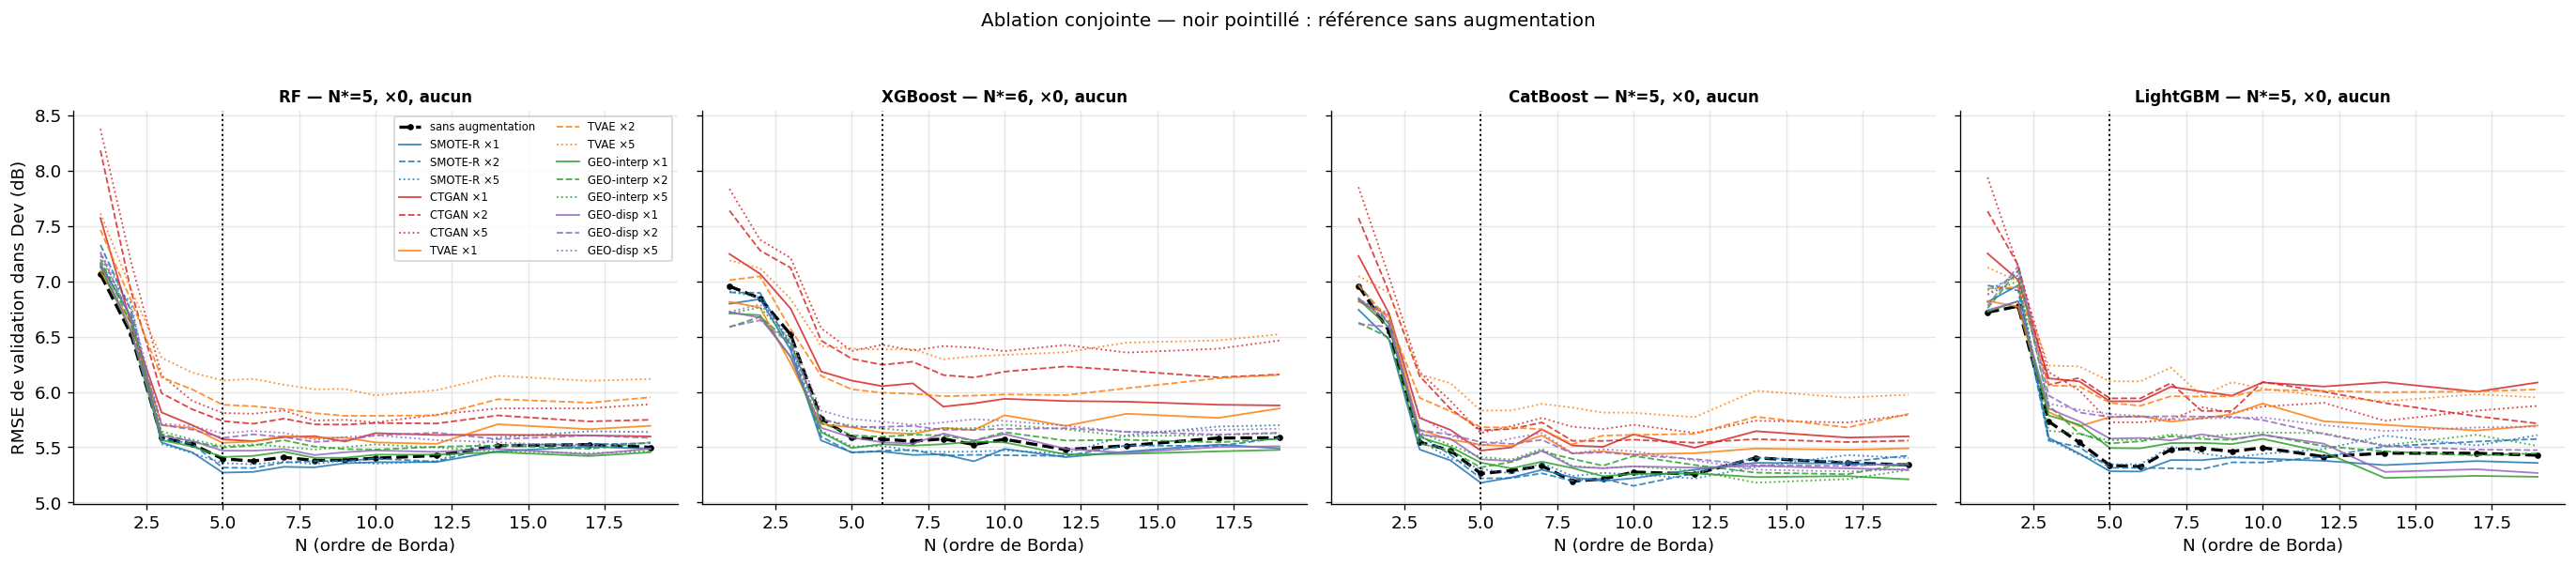

In [13]:
# ── Surface (N, ratio) par modèle ───────────────────────────────────────────
COUL = {'SMOTE-R':'tab:blue','CTGAN':'tab:red','TVAE':'tab:orange',
        'GEO-interp':'tab:green','GEO-disp':'tab:purple'}
fig, axes = plt.subplots(1, 4, figsize=(23,4.8), sharey=True)
for ax, mdl in zip(axes, ML_NAMES):
    s = agg[agg.model==mdl]
    z = s[s['générateur']=='aucun'].sort_values('N')
    ax.plot(z.N, z['mean'], color='k', ls='--', lw=2, marker='o', markersize=3,
            label='sans augmentation')
    for gname in GENERATEURS:
        for ratio, style in zip([1,2,5], ['-','--',':']):
            ss = s[(s['générateur']==gname) & (s.ratio==ratio)].sort_values('N')
            if len(ss)==0: continue
            ax.plot(ss.N, ss['mean'], color=COUL[gname], ls=style, lw=1.1, alpha=0.85,
                    label=f'{gname} ×{ratio}' if mdl==ML_NAMES[0] else None)
    r = selection[selection.model==mdl].iloc[0]
    ax.axvline(r['N*'], color='k', ls=':', lw=1.2)
    ax.set_title(f"{mdl} — N*={int(r['N*'])}, ×{int(r['ratio*'])}, {r['gen*']}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('N (ordre de Borda)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE de validation dans Dev (dB)')
axes[0].legend(fontsize=7, ncol=2)
plt.suptitle('Ablation conjointe — noir pointillé : référence sans augmentation', fontsize=12, y=1.04)
plt.tight_layout(); plt.savefig(OUT/'fig_ablation.pdf', bbox_inches='tight')
plt.savefig(OUT/'fig_ablation.png', dpi=150, bbox_inches='tight'); plt.show()

---
## §9 — Évaluation finale sur le test scellé

Le test est rouvert ici pour la première fois. Deux configurations par modèle : celle du notebook 07 (N\* sans augmentation) et celle retenue au §8. L'écart est rapporté avec un **intervalle de confiance bootstrap apparié** (2000 rééchantillonnages) et un test de Wilcoxon apparié sur les erreurs absolues — un ΔRMSE nu, sans intervalle, ne dit rien à cette taille d'échantillon.

In [14]:
bandeau('CE QUI SE PASSE ICI', [
  'Les générateurs sont réentraînés sur Dev ENTIER (et non plus sur k−1 plis), avec la',
  'configuration retenue au §8, puis chaque modèle est ajusté une fois et évalué sur le test.',
  'Le test n a servi à choisir strictement rien : ni le générateur, ni le ratio, ni N, ni les',
  'hyperparamètres, qui viennent du notebook 07.'])

y_te   = test_df[TARGET].values
n_base = dev_df.groupby('stratum').size().to_dict()
n_max  = {s: n*MAX_RATIO for s, n in n_base.items()}
SYN_F  = {}
besoin = set(selection['gen*']) - {'aucun'}
for gname in besoin:
    if gname.startswith('GEO'):
        if 'GEO' not in SYN_F:
            SYN_F['GEO'], _ = build_synthetic(dev_df, n_max, np.random.default_rng(SEED),
                                              tag=f'final_x{MAX_RATIO}')
        SYN_F[gname] = SYN_F['GEO']
    else:
        SYN_F[gname] = augment_tabulaire(dev_df, n_max, gname, np.random.default_rng(SEED), B_dev)
    print(f'  {gname:12s} {len(SYN_F[gname])} points synthétiques prêts')
YCOL = {'SMOTE-R':TARGET,'CTGAN':TARGET,'TVAE':TARGET,'GEO-interp':'E_interp','GEO-disp':'E_disp'}

rows, preds = [], {}
for _, r in selection.iterrows():
    mdl = r['model']
    fe07 = BORDA_ORDER[:r['N*_nb07']]
    m = build_ml(mdl); m.fit(dev_df[fe07].values, dev_df[TARGET].values)
    p0 = m.predict(test_df[fe07].values); preds[(mdl,'ref')] = p0
    rows.append({'model':mdl,'config':f"nb07 : N={r['N*_nb07']}, sans augmentation", **evaluate(y_te,p0)})

    fe = BORDA_ORDER[:r['N*']]
    if r['ratio*'] == 0:
        data = dev_df[ALL_FEATURES+[TARGET]]
    else:
        src  = SYN_F[r['gen*']]
        keep = src.groupby('stratum', group_keys=False).apply(
            lambda g: g.head(int(n_base.get(g.name,0)*r['ratio*'])))
        part = keep[ALL_FEATURES].copy(); part[TARGET] = keep[YCOL[r['gen*']]].values
        data = pd.concat([dev_df[ALL_FEATURES+[TARGET]], part], ignore_index=True)
    m = build_ml(mdl); m.fit(data[fe].values, data[TARGET].values)
    p1 = m.predict(test_df[fe].values); preds[(mdl,'aug')] = p1
    rows.append({'model':mdl,'config':f"retenu : N={r['N*']}, ×{r['ratio*']}, {r['gen*']}",
                 **evaluate(y_te,p1)})

fin = pd.DataFrame(rows)
for c in ['RMSE','MAE','Bias']: fin[c] = fin[c].round(3)
fin['R2'] = fin['R2'].round(3)
fin.to_csv(OUT/'resultats_test.csv', index=False)
print()
print(f'=== Test scellé (n={len(test_df)}) ===')
print(fin.to_string(index=False))


══════════════════════════════════════════════════════════════════════════════
  CE QUI SE PASSE ICI
══════════════════════════════════════════════════════════════════════════════
  Les générateurs sont réentraînés sur Dev ENTIER (et non plus sur k−1
    plis), avec la
  configuration retenue au §8, puis chaque modèle est ajusté une fois et
    évalué sur le test.
  Le test n a servi à choisir strictement rien : ni le générateur, ni le
    ratio, ni N, ni les
  hyperparamètres, qui viennent du notebook 07.




=== Test scellé (n=66) ===
   model                        config  RMSE   MAE    R2  Bias
      RF nb07 : N=4, sans augmentation 4.846 4.064 0.760 0.427
      RF       retenu : N=5, ×0, aucun 4.675 3.960 0.777 0.534
 XGBoost nb07 : N=5, sans augmentation 4.960 4.018 0.749 0.704
 XGBoost       retenu : N=6, ×0, aucun 4.857 3.944 0.759 0.703
CatBoost nb07 : N=4, sans augmentation 5.195 4.311 0.724 0.634
CatBoost       retenu : N=5, ×0, aucun 4.817 4.076 0.763 0.721
LightGBM nb07 : N=5, sans augmentation 4.884 3.966 0.756 0.628
LightGBM       retenu : N=5, ×0, aucun 4.884 3.966 0.756 0.628


In [15]:
# ── Intervalles bootstrap appariés + Wilcoxon ──────────────────────────────
n = len(y_te); rngb = np.random.default_rng(SEED); IDX = rngb.integers(0, n, size=(2000, n))
rows = []
for mdl in ML_NAMES:
    a, b = preds[(mdl,'aug')], preds[(mdl,'ref')]
    d_pt = float(np.sqrt(mean_squared_error(y_te,a)) - np.sqrt(mean_squared_error(y_te,b)))
    d_bs = np.array([np.sqrt(mean_squared_error(y_te[i],a[i])) -
                     np.sqrt(mean_squared_error(y_te[i],b[i])) for i in IDX])
    lo, hi = np.percentile(d_bs, [2.5, 97.5])
    w = stats.wilcoxon(np.abs(y_te-a), np.abs(y_te-b), zero_method='zsplit')
    rows.append({'model':mdl,'ΔRMSE':round(d_pt,3),'IC_lo':round(lo,3),'IC_hi':round(hi,3),
                 'P(retenu meilleur)':round(float((d_bs<0).mean()),3),
                 'Wilcoxon_p':round(float(w.pvalue),4)})
cmp_df = pd.DataFrame(rows); cmp_df.to_csv(OUT/'test_apparie.csv', index=False)

bandeau('CONFIGURATION RETENUE VS NB07 — TEST SCELLÉ', [
  'ΔRMSE < 0 : la configuration retenue fait mieux.',
  'Un intervalle qui contient zéro veut dire qu à 66 points de test, l effet n est pas',
  'distinguable du bruit d échantillonnage — ce n est pas la même chose qu une absence d effet.'])
print(cmp_df.to_string(index=False))
print()
if all((r.IC_lo <= 0 <= r.IC_hi) for r in cmp_df.itertuples()):
    print('Conclusion : AUCUN GAIN ÉTABLI — tous les intervalles contiennent zéro.')
else:
    print('Conclusion : au moins un modèle montre un effet dont l intervalle exclut zéro.')


══════════════════════════════════════════════════════════════════════════════
  CONFIGURATION RETENUE VS NB07 — TEST SCELLÉ
══════════════════════════════════════════════════════════════════════════════
  ΔRMSE < 0 : la configuration retenue fait mieux.
  Un intervalle qui contient zéro veut dire qu à 66 points de test, l effet
    n est pas
  distinguable du bruit d échantillonnage — ce n est pas la même chose qu
    une absence d effet.

   model  ΔRMSE  IC_lo  IC_hi  P(retenu meilleur)  Wilcoxon_p
      RF -0.170 -0.363  0.029               0.952      0.3022
 XGBoost -0.103 -0.306  0.093               0.860      0.1444
CatBoost -0.378 -0.663 -0.059               0.993      0.1245
LightGBM  0.000  0.000  0.000               0.000      1.0000

Conclusion : au moins un modèle montre un effet dont l intervalle exclut zéro.


---
## §9bis — Évaluation sur le test scellé, toutes les combinaisons (générateur, ratio)

Extension du §9 : au lieu de ne réévaluer que la configuration retenue par la règle du
plateau, chaque combinaison (générateur, ratio, N optimal en CV) est réentraînée sur Dev
entier et évaluée une fois sur le test scellé (n=66). Le test ne sert toujours qu'à mesurer,
jamais à choisir : le N de chaque ligne vient de la grille de CV du §7, pas d'une recherche
sur le test.

In [ ]:
bandeau('CE QUE FAIT CETTE CELLULE', [
  'Étend le §9 à toute la grille : chaque (générateur, ratio) est réentraîné sur Dev entier,',
  'au N choisi par la règle du plateau à 1 erreur type SUR SA PROPRE courbe N -> RMSE (même',
  'principe que pick_nstar en nb07/nb08 — pas un argmin brut, pour ne pas sur-ajuster au bruit',
  'de la CV), puis évalué UNE fois sur le test scellé.',
  'La règle est appliquée UNIFORMÉMENT, y compris à "aucun" — aucun cas particulier. Comme la',
  'grille du §7 utilise désormais les mêmes plis (RepeatedKFold 5x2) et les mêmes hyperparamètres',
  'que l ablation Pure ML de nb07, le N retenu ici pour "aucun" doit coïncider avec NSTAR (le N*',
  'de nb07 / Table 6) par construction — vérifié ci-dessous, pas juste affirmé.',
  "Les générateurs pas encore matérialisés sur Dev entier (typiquement CTGAN, TVAE) sont",
  'générés ici — seule étape coûteuse de cette cellule, le reste est de simples ajustements.'])

def pick_nstar_cell(sub):
    '''Règle du plateau à 1 erreur type, appliquée à la courbe N -> RMSE d une seule cellule
       (modèle, générateur, ratio) — identique en principe à pick_nstar (nb07/nb08/nb09).'''
    sub = sub.sort_values('N')
    mu, se, Nv = sub['mean'].values, sub['se'].values, sub['N'].values
    j = int(np.argmin(mu))
    thr = mu[j] + se[j]
    return int(Nv[np.argmax(mu <= thr)])

best_N = {}
for (mdl, gname, ratio), sub in agg.groupby(['model', 'générateur', 'ratio']):
    best_N[(mdl, gname, ratio)] = pick_nstar_cell(sub)

N0 = {mdl: best_N[(mdl, 'aucun', 0)] for mdl in ML_NAMES}

print('=== Contrôle — N("aucun") calculé ici, vs NSTAR (nb07 / Table 6) ===')
for mdl in ML_NAMES:
    same = '=' if N0[mdl] == NSTAR[mdl] else '≠'
    print(f'  {mdl:10s} N ici (RepeatedKFold 5x2) = {N0[mdl]:2d}   {same}   NSTAR (nb07) = {NSTAR[mdl]}')

# Génération sur Dev entier pour TOUS les générateurs (pas seulement ceux retenus au §8)
for gname in GENERATEURS:
    if gname in SYN_F:
        continue
    if gname.startswith('GEO'):
        if 'GEO' not in SYN_F:
            SYN_F['GEO'], _ = build_synthetic(dev_df, n_max, np.random.default_rng(SEED),
                                              tag=f'final_x{MAX_RATIO}')
        SYN_F[gname] = SYN_F['GEO']
    else:
        SYN_F[gname] = augment_tabulaire(dev_df, n_max, gname, np.random.default_rng(SEED), B_dev)
    print(f'  {gname:12s} {len(SYN_F[gname])} points synthétiques prêts')

rows_full = []
for mdl in ML_NAMES:
    fe0 = BORDA_ORDER[:N0[mdl]]
    m = build_ml(mdl); m.fit(dev_df[fe0].values, dev_df[TARGET].values)
    p0 = m.predict(test_df[fe0].values)
    rows_full.append({'model': mdl, 'générateur': 'aucun', 'ratio': 0, 'N': N0[mdl],
                      **evaluate(y_te, p0)})

    for gname in GENERATEURS:
        for ratio in [1, 2, 5]:
            N = best_N.get((mdl, gname, ratio))
            if N is None:
                continue
            fe = BORDA_ORDER[:N]
            src = SYN_F[gname]
            keep = src.groupby('stratum', group_keys=False).apply(
                lambda g: g.head(int(n_base.get(g.name, 0) * ratio)))
            part = keep[ALL_FEATURES].copy(); part[TARGET] = keep[YCOL[gname]].values
            data = pd.concat([dev_df[ALL_FEATURES + [TARGET]], part], ignore_index=True)
            m = build_ml(mdl); m.fit(data[fe].values, data[TARGET].values)
            p = m.predict(test_df[fe].values)
            rows_full.append({'model': mdl, 'générateur': gname, 'ratio': ratio, 'N': N,
                              **evaluate(y_te, p)})

full_grid_test = pd.DataFrame(rows_full)
for c in ['RMSE', 'MAE', 'Bias']: full_grid_test[c] = full_grid_test[c].round(3)
full_grid_test['R2'] = full_grid_test['R2'].round(3)
full_grid_test.to_csv(OUT / 'resultats_test_tous_ratios.csv', index=False)

# Contrôle secondaire : si "retenu" (§8/§9) est aussi 'aucun' pour un modèle, sa RMSE doit
# coïncider avec la ligne "aucun" ci-dessus (même N, mêmes données) — imprimé pour preuve.
# Si "retenu" a basculé sur un autre générateur avec ce nouveau protocole, ce n'est PAS une
# incohérence : la règle du plateau a simplement pu changer d avis avec 2x plus d estimations.
print('\n=== Contrôle secondaire — ligne "aucun" ici vs "retenu" en §9 (mêmes SEULEMENT si gen*=aucun) ===')
check = full_grid_test[full_grid_test['générateur']=='aucun'][['model','N','RMSE']]
ref = fin[fin['config'].str.startswith('retenu')][['model','RMSE']].rename(columns={'RMSE':'RMSE_retenu_§9'})
retenu_gen = dict(zip(selection['model'], selection['gen*']))
merged = check.merge(ref, on='model')
merged['gen*_retenu'] = merged['model'].map(retenu_gen)
print(merged.to_string(index=False))

order = ['aucun'] + GENERATEURS
print(f'\n=== Test scellé (n={len(test_df)}) — RMSE (dB), toutes combinaisons, plateau 1SE par cellule ===')
piv_test = full_grid_test.pivot(index=['générateur', 'ratio'], columns='model', values='RMSE')
piv_test = piv_test.reindex(order, level='générateur')
print(piv_test.to_string())


---
## §9ter — Table à N fixé : isoler l'effet net de l'augmentation

Contrairement au §9bis (N optimisé par cellule), ici **N est fixé à NSTAR (le N* de nb07,
sans augmentation) pour toute la ligne** de chaque modèle — aucun, et les 15 combinaisons
générateur × ratio. Objectif : neutraliser le confondu repéré précédemment (ex. GEO-disp
donnant à LightGBM un N=14 très différent du N=5 de la référence), pour que tout écart de
RMSE ne puisse venir que du générateur/ratio, pas d'un changement de complexité de modèle.
Chaque cellule est comparée à "aucun" (même N, même modèle) par IC bootstrap apparié (2000
rééchantillonnages) et test de Wilcoxon apparié — comme au §9.

Cette table est **complémentaire** à celle du §9bis, pas un remplacement : le §9bis répond à
« quelle est la meilleure performance atteignable dans chaque régime d'augmentation ? »,
celle-ci répond à « à complexité de modèle égale, l'augmentation apporte-t-elle un gain net ? »


In [ ]:
bandeau('CE QUE FAIT CETTE CELLULE', [
  'Pour chaque modèle, N est fixé à NSTAR (le N* de nb07, sans augmentation) sur TOUTE la',
  'ligne (aucun + les 15 combinaisons générateur x ratio) — pas de N optimisé par cellule ici.',
  'Objectif : isoler l effet net de l augmentation à complexité de modèle strictement',
  'identique, sans confondre un gain avec un changement de N.',
  'Chaque cellule est comparée à "aucun" (même N, même modèle) par IC bootstrap apparié',
  '(2000 rééchantillonnages) et test de Wilcoxon apparié — comme au §9.'])

rows_fixed, preds_fixed = [], {}
for mdl in ML_NAMES:
    N = NSTAR[mdl]
    fe = BORDA_ORDER[:N]

    m = build_ml(mdl); m.fit(dev_df[fe].values, dev_df[TARGET].values)
    p0 = m.predict(test_df[fe].values)
    preds_fixed[(mdl, 'aucun', 0)] = p0
    rows_fixed.append({'model': mdl, 'générateur': 'aucun', 'ratio': 0, 'N': N,
                       **evaluate(y_te, p0)})

    for gname in GENERATEURS:
        for ratio in [1, 2, 5]:
            src = SYN_F[gname]
            keep = src.groupby('stratum', group_keys=False).apply(
                lambda g: g.head(int(n_base.get(g.name, 0) * ratio)))
            part = keep[ALL_FEATURES].copy(); part[TARGET] = keep[YCOL[gname]].values
            data = pd.concat([dev_df[ALL_FEATURES + [TARGET]], part], ignore_index=True)
            m = build_ml(mdl); m.fit(data[fe].values, data[TARGET].values)
            p = m.predict(test_df[fe].values)
            preds_fixed[(mdl, gname, ratio)] = p
            rows_fixed.append({'model': mdl, 'générateur': gname, 'ratio': ratio, 'N': N,
                               **evaluate(y_te, p)})

full_grid_fixed = pd.DataFrame(rows_fixed)
for c in ['RMSE', 'MAE', 'Bias']: full_grid_fixed[c] = full_grid_fixed[c].round(3)
full_grid_fixed['R2'] = full_grid_fixed['R2'].round(3)
full_grid_fixed.to_csv(OUT / 'resultats_test_N_fixe.csv', index=False)

print('=== Contrôle — ligne "aucun" à N fixé doit reproduire Table 6 (nb07) exactement ===')
check = full_grid_fixed[full_grid_fixed['générateur']=='aucun'][['model','N','RMSE','R2']]
print(check.to_string(index=False))

order = ['aucun'] + GENERATEURS
print(f'\n=== Test scellé (n={len(test_df)}) — RMSE (dB), N FIXÉ à NSTAR par modèle ===')
piv_fixed = full_grid_fixed.pivot(index=['générateur', 'ratio'], columns='model', values='RMSE')
piv_fixed = piv_fixed.reindex(order, level='générateur')
print(piv_fixed.to_string())

# ── IC bootstrap apparié + Wilcoxon, chaque cellule vs "aucun" au même N fixé ────────────
n = len(y_te); rngb2 = np.random.default_rng(SEED); IDX2 = rngb2.integers(0, n, size=(2000, n))
rows_cmp = []
for mdl in ML_NAMES:
    b = preds_fixed[(mdl, 'aucun', 0)]
    for gname in GENERATEURS:
        for ratio in [1, 2, 5]:
            a = preds_fixed[(mdl, gname, ratio)]
            d_pt = float(np.sqrt(mean_squared_error(y_te, a)) - np.sqrt(mean_squared_error(y_te, b)))
            d_bs = np.array([np.sqrt(mean_squared_error(y_te[i], a[i])) -
                             np.sqrt(mean_squared_error(y_te[i], b[i])) for i in IDX2])
            lo, hi = np.percentile(d_bs, [2.5, 97.5])
            w = stats.wilcoxon(np.abs(y_te-a), np.abs(y_te-b), zero_method='zsplit')
            rows_cmp.append({'model': mdl, 'générateur': gname, 'ratio': ratio,
                             'ΔRMSE_vs_aucun': round(d_pt, 3), 'IC_lo': round(lo, 3),
                             'IC_hi': round(hi, 3),
                             'P(gen meilleur)': round(float((d_bs < 0).mean()), 3),
                             'Wilcoxon_p': round(float(w.pvalue), 4)})
cmp_fixed = pd.DataFrame(rows_cmp)
cmp_fixed.to_csv(OUT / 'test_apparie_N_fixe.csv', index=False)

print(f'\n=== IC bootstrap 95% + Wilcoxon, chaque (générateur, ratio) vs "aucun" au même N fixé ===')
print(cmp_fixed.to_string(index=False))

n_sig = int((cmp_fixed['Wilcoxon_p'] < 0.05).sum())
n_ic_excl_0 = int(((cmp_fixed['IC_lo'] > 0) | (cmp_fixed['IC_hi'] < 0)).sum())
print(f'\nSur {len(cmp_fixed)} comparaisons : {n_sig} significative(s) (Wilcoxon p<0.05), '
      f'{n_ic_excl_0} avec IC excluant zéro.')


---
## §9quater — Synthèse pour le manuscrit : meilleure config par modèle + test du signe

Deux résultats discutés mais pas encore sauvegardés : (1) la meilleure configuration
alternative à "aucun" pour chaque modèle (table à N fixé), et (2) un test du signe sur les
configurations GEO-interp/GEO-disp aux ratios ×1-×2, qui agrège 16 comparaisons
faibles-mais-cohérentes en une seule affirmation statistiquement plus solide qu'aucune
comparaison individuelle (chacune sous-puissante à n=66).


In [33]:
bandeau('CE QUE FAIT CETTE CELLULE', [
  'Synthèse pour le manuscrit, à partir de la table à N fixé (§9ter) :',
  '  1. la meilleure configuration alternative à "aucun", pour chaque modèle ;',
  '  2. un test du signe sur les configurations GEO-interp/GEO-disp aux ratios x1-x2 —',
  '     14/16 améliorations attendraient 50% par hasard ; le test du signe chiffre à quel',
  '     point ce n en est pas un.'])

from scipy.stats import binomtest

# 1) Meilleure alternative à "aucun", par modèle ---------------------------------------
best_rows = []
for mdl in ML_NAMES:
    rmse_aucun = full_grid_fixed[(full_grid_fixed.model == mdl) &
                                  (full_grid_fixed['générateur'] == 'aucun')]['RMSE'].iloc[0]
    sub = cmp_fixed[cmp_fixed.model == mdl].sort_values('ΔRMSE_vs_aucun')
    b = sub.iloc[0]
    best_rows.append({
        'model': mdl, 'N': NSTAR[mdl], 'RMSE_aucun': rmse_aucun,
        'meilleur_generateur': b['générateur'], 'meilleur_ratio': int(b['ratio']),
        'RMSE_meilleur': round(rmse_aucun + b['ΔRMSE_vs_aucun'], 3),
        'delta': b['ΔRMSE_vs_aucun'], 'IC_lo': b['IC_lo'], 'IC_hi': b['IC_hi'],
        'Wilcoxon_p': b['Wilcoxon_p']})
best_par_modele = pd.DataFrame(best_rows)
best_par_modele.to_csv(OUT / 'meilleure_config_par_modele_N_fixe.csv', index=False)
print('=== Meilleure configuration alternative à "aucun", par modèle (N fixé) ===')
print(best_par_modele.to_string(index=False))

# 2) Test du signe — GEO-interp/GEO-disp, ratios x1-x2 ----------------------------------
geo12 = cmp_fixed[(cmp_fixed['générateur'].isin(['GEO-interp', 'GEO-disp'])) &
                  (cmp_fixed.ratio.isin([1, 2]))]
k = int((geo12['ΔRMSE_vs_aucun'] < 0).sum()); n = len(geo12)
bt = binomtest(k, n, 0.5, alternative='greater')
sign_test = pd.DataFrame([{
    'sous_ensemble': 'GEO-interp + GEO-disp, ratios x1-x2',
    'n_cellules': n, 'n_ameliorations': k, 'proportion': round(k / n, 3),
    'p_value_binomiale': round(bt.pvalue, 4)}])
sign_test.to_csv(OUT / 'test_du_signe_GEO.csv', index=False)
print(f'\n=== Test du signe — GEO-interp/GEO-disp, ratios x1-x2 ===')
print(f'{k}/{n} cellules améliorent "aucun" (H0 : 50% par hasard) — p = {bt.pvalue:.4f}')

# Contexte : même décompte pour la famille GEO au complet et pour les autres générateurs
print('\n=== Pour contexte — proportion de cellules qui améliorent "aucun" ===')
for label, mask in [
    ('GEO (interp+disp), tous ratios      ', cmp_fixed['générateur'].isin(['GEO-interp', 'GEO-disp'])),
    ('SMOTE-R/CTGAN/TVAE, tous ratios     ', ~cmp_fixed['générateur'].isin(['GEO-interp', 'GEO-disp']))]:
    sub = cmp_fixed[mask]
    k2 = int((sub['ΔRMSE_vs_aucun'] < 0).sum()); n2 = len(sub)
    print(f'  {label} : {k2}/{n2} améliorations ({100*k2/n2:.0f}%)')



══════════════════════════════════════════════════════════════════════════════
  CE QUE FAIT CETTE CELLULE
══════════════════════════════════════════════════════════════════════════════
  Synthèse pour le manuscrit, à partir de la table à N fixé (§9ter) :
    1. la meilleure configuration alternative à "aucun", pour chaque modèle
    ;
    2. un test du signe sur les configurations GEO-interp/GEO-disp aux
    ratios x1-x2 —
       14/16 améliorations attendraient 50% par hasard ; le test du signe
    chiffre à quel
       point ce n en est pas un.

=== Meilleure configuration alternative à "aucun", par modèle (N fixé) ===
   model  N  RMSE_aucun meilleur_generateur  meilleur_ratio  RMSE_meilleur  delta  IC_lo  IC_hi  Wilcoxon_p
      RF  4       4.846            GEO-disp               1          4.671 -0.175 -0.437  0.068      0.3938
 XGBoost  5       4.960            GEO-disp               2          4.477 -0.483 -0.901 -0.080      0.2515
CatBoost  4       5.195            GEO-disp  

---
## §10 — Ce que ce notebook établit

**Quatre générateurs comparés, pas un seul retenu d'avance.** SMOTE-R, CTGAN et TVAE représentent la famille tabulaire sous contraintes ; GEO-interp et GEO-disp la famille *dependency-aware*, où seule la position est tirée et le reste recalculé. Le §6 montre lesquels respectent la distribution réelle, le §8 lequel gagne en validation, le §9 si ce gain survit au test.

**La taille se choisit en validation, sur une grille géométrique**, conjointement avec N et le générateur, par la règle du plateau à une erreur type. Le §8 chiffre l'optimisme de sélection qu'un balayage au pas de 1 introduirait.

**Seuls les k−1 plis d'entraînement sont augmentés**, conformément à Santos et al. (2018), et le §7.1 en donne l'audit chiffré plutôt qu'une phrase de méthodologie.

**La météo n'est jamais fabriquée** : le bloc entier est hérité d'une session réelle, donc sa distribution jointe est préservée exactement.

### Fichiers produits dans `outputs_augmentation/`

| Fichier | Contenu |
|---|---|
| `conformite_distribution.csv` | moments, KS et bornes, par générateur et par feature |
| `conformite_cible_par_strate.csv` | dispersion de la cible, α calibré, par strate |
| `grille_ablation.csv` | la grille complète, une ligne par (pli, générateur, ratio, N, modèle) |
| `audit_plis.csv` | composition des plis et compteurs de fuite |
| `selection_conjointe.csv` | argmin et configuration retenue, par modèle |
| `resultats_test.csv` | RMSE, MAE, R², biais sur le test scellé |
| `test_apparie.csv` | ΔRMSE, intervalles bootstrap, Wilcoxon |
| `fig_ablation.pdf/.png` | surfaces (N, ratio) pour les quatre modèles |

### Références du positionnement

- Torgo & Ribeiro, *SMOTE for regression* — et Branco, Torgo & Ribeiro, « SMOGN », PMLR 74, 2017.
- Xu, Skoularidou, Cuesta-Infante & Veeramachaneni, « Modeling Tabular Data using Conditional GAN », NeurIPS 2019 (arXiv:1907.00503) — CTGAN et TVAE.
- Stoian, Dyrmishi, Cordy, Lukasiewicz & Giunchiglia, « How Realistic Is Your Synthetic Data? Constraining Deep Generative Models for Tabular Data », ICLR 2024 (arXiv:2402.04823).
- Umesha, Schultz, Mahendra, Bej & Wolkenhauer, « Dependency-aware synthetic tabular data generation », arXiv:2507.19211, 2025.
- Mohamed, Lee, Zhang, Hollingsworth, Anderson, Krogmeier & Love, « Simulation-Enhanced Data Augmentation for Machine Learning Pathloss Prediction », arXiv:2402.01969.
- Santos, Soares, Abreu, Araújo & Santos, « Cross-Validation for Imbalanced Datasets », IEEE Comput. Intell. Mag. 13(4), 2018.
- Demircioğlu, « Applying oversampling before cross-validation will lead to high bias in radiomics », Sci. Rep. 14:11563, 2024.
- Cawley & Talbot, « On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation », JMLR 11:2079–2107, 2010.

Vérifie chaque référence avant de la citer dans le manuscrit : elles proviennent d'une recherche documentaire, et deux d'entre elles n'ont été confirmées que par leur notice, pas par lecture intégrale.
